# PropertyLens Price Prediction (Sample)

这个 notebook 演示一个可解释的预测方案：

- `Model A`：仅使用房屋本体属性（楼层、面积、房间数、租约）
- `Model B`：学习区位与配套（MRT、食阁、商业体、学校）对价格的增量影响
- 最终价格：`pred = pred_structural + pred_context`

这样可以自然拆分价格贡献占比，满足“要展示各因素对房价占比”的需求。

## MOE P1 Balloting Logic Used In Model

Based on MOE pages `How distance affects priority admission` and `Understand how balloting works`:

- Priority distance buckets are: `within 1km`, `between 1km and 2km`, `outside 2km`.
- Balloting priority sequence is by citizenship + distance: SC (1km, 1-2km, >2km), then PR (1km, 1-2km, >2km).
- Balloting may happen from Phase 2A to 2C Supplementary when applicants exceed vacancies.

Modeling choices in this notebook:

- `school_admission_priority_weight`: distance-stage weight (`1.0`, `0.55`, `0.15`).
- `school_competition_pct`: school competitiveness percentile from historical registration competition proxy.
- `school_tier_effective = school_competition_pct * school_admission_priority_weight`.
- `school_1km_completion_proxy`: additional high-competition signal inside 1km.

Note: Current training data has no citizenship field, so we only model distance-stage priority effect.

In [3]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 120)

In [4]:
@dataclass
class PredictConfig:
    processed_path: Path = Path.cwd() / "data" / "processed" / "training_dataset.parquet"
    random_state: int = 42
    test_size: float = 0.2


cfg = PredictConfig()
cfg

PredictConfig(processed_path=PosixPath('/Users/lorenzolou/Library/Mobile Documents/com~apple~CloudDocs/NUS/PropertyLens/data/processed/training_dataset.parquet'), random_state=42, test_size=0.2)

In [5]:
wanted_cols = [
    "year", "month", "town", "flat_type", "address", "resale_price",
    "level_mid", "lease_years_left", "floor_area_sqm", "room_count",
    "dist_mrt_km", "dist_foodcourt_km", "num_malls_2km",
    "nearest_school_dist_km", "schools_within_1km", "best_school_tier_score",
]

df = pd.DataFrame()
source_used = ""

try:
    # 优先 parquet，速度更快
    df_parquet = pd.read_parquet(cfg.processed_path)
    if not df_parquet.empty:
        keep = [c for c in wanted_cols if c in df_parquet.columns]
        df = df_parquet[keep].copy() if keep else df_parquet.copy()
        source_used = str(cfg.processed_path)
except Exception as e:
    print(f"Parquet load failed, fallback to CSV: {e}")

if df.empty:
    csv_path = cfg.processed_path.with_suffix(".csv")
    header = pd.read_csv(csv_path, nrows=0)
    usecols = [c for c in wanted_cols if c in header.columns]
    df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
    source_used = str(csv_path)

print("data source:", source_used)
print("shape:", df.shape)
df.head(5)

data source: /Users/lorenzolou/Library/Mobile Documents/com~apple~CloudDocs/NUS/PropertyLens/data/processed/training_dataset.parquet
shape: (972474, 16)


,year,month,town,flat_type,address,resale_price,level_mid,lease_years_left,floor_area_sqm,room_count,dist_mrt_km,dist_foodcourt_km,num_malls_2km,nearest_school_dist_km,schools_within_1km,best_school_tier_score
0,1990,1990-01,ANG MO KIO,1 ROOM,309 ANG MO KIO AVE 1,9000.0,11.0,86,31.0,1.0,1.252222,0.672322,0.0,0.137805,50.0,3.0
1,1990,1990-01,ANG MO KIO,1 ROOM,309 ANG MO KIO AVE 1,6000.0,5.0,86,31.0,1.0,1.252222,0.672322,0.0,0.137805,50.0,3.0
2,1990,1990-01,ANG MO KIO,1 ROOM,309 ANG MO KIO AVE 1,8000.0,11.0,86,31.0,1.0,1.252222,0.672322,0.0,0.137805,50.0,3.0
3,1990,1990-01,ANG MO KIO,1 ROOM,309 ANG MO KIO AVE 1,6000.0,8.0,86,31.0,1.0,1.252222,0.672322,0.0,0.137805,50.0,3.0
4,1990,1990-01,ANG MO KIO,3 ROOM,216 ANG MO KIO AVE 1,47200.0,5.0,85,73.0,3.0,0.990384,0.199932,0.0,0.498246,30.0,2.0


In [6]:
target_col = "resale_price"

# 保证 year 维度存在
if "year" not in df.columns:
    if "month" in df.columns:
        df["year"] = pd.to_datetime(df["month"].astype(str) + "-01", errors="coerce").dt.year
    else:
        df["year"] = np.nan

# 提取项目名称：从 address 中获取（通常是最后一个关键词）
def extract_project_name(addr_str):
    if not isinstance(addr_str, str) or len(addr_str.strip()) == 0:
        return "UNKNOWN"
    parts = addr_str.strip().split()
    if len(parts) >= 2:
        return " ".join(parts[:2]) if len(parts) <= 3 else " ".join(parts[-2:])
    return addr_str.strip()


def haversine_km_np(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(np.asarray(lon1, dtype=float))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat1 - lat2
    dlon = lon1 - lon2
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))


df["project_name"] = df["address"].apply(extract_project_name)

# 依据 MOE 距离优先规则构造学区特征：<=1km, 1-2km, >2km
school_dist = pd.to_numeric(df.get("nearest_school_dist_km"), errors="coerce")
df["school_within_1km_flag"] = (school_dist <= 1.0).astype(float)
df["school_within_2km_flag"] = (school_dist <= 2.0).astype(float)
df["school_distance_band"] = np.select(
    [school_dist <= 1.0, school_dist <= 2.0],
    [3.0, 2.0],
    default=1.0,
)

df["school_admission_priority_weight"] = np.select(
    [school_dist <= 1.0, school_dist <= 2.0],
    [1.0, 0.55],
    default=0.15,
)

school_comp_raw = pd.to_numeric(df.get("best_school_tier_score"), errors="coerce")
if school_comp_raw.notna().any():
    school_comp_raw = school_comp_raw.fillna(school_comp_raw.median())
else:
    school_comp_raw = pd.Series(0.0, index=df.index)

df["school_competition_pct"] = school_comp_raw.rank(pct=True)
ratio = school_comp_raw.copy()
df["phase1_pressure_proxy"] = np.clip(ratio / 1.5, 0, 1)
df["phase2a_pressure_proxy"] = np.clip((ratio - 0.60) / 0.90, 0, 1)
df["phase2b_pressure_proxy"] = np.clip((ratio - 0.80) / 0.90, 0, 1)
df["phase2c_pressure_proxy"] = np.clip((ratio - 1.00) / 0.90, 0, 1)
df["phase2cs_pressure_proxy"] = np.clip((ratio - 1.20) / 0.90, 0, 1)

df["school_tier_effective"] = df["school_competition_pct"] * df["school_admission_priority_weight"]
df["school_count_effective"] = (
    pd.to_numeric(df.get("schools_within_1km"), errors="coerce").fillna(0).clip(lower=0)
    * df["school_admission_priority_weight"]
)
df["school_1km_completion_proxy"] = df["school_competition_pct"] * df["school_within_1km_flag"]

addr_geo_path = Path.cwd() / "data" / "interim" / "address_geocode.csv"
school_geo_path = Path.cwd() / "data" / "interim" / "school_geocode.csv"
addr_geo_tmp = pd.read_csv(addr_geo_path)
school_geo_tmp = pd.read_csv(school_geo_path)

addr_col_lat = "latitude" if "latitude" in addr_geo_tmp.columns else "lat"
addr_col_lon = "longitude" if "longitude" in addr_geo_tmp.columns else "lon"

addr_points = (
    addr_geo_tmp[["address", addr_col_lat, addr_col_lon]]
    .drop_duplicates("address")
    .copy()
)
addr_points = addr_points.rename(columns={addr_col_lat: "lat", addr_col_lon: "lon"})

school_points_tmp = (
    school_geo_tmp[["school_name", "school_lat", "school_lon"]]
    .dropna(subset=["school_lat", "school_lon"])
    .drop_duplicates("school_name")
    .copy()
)

addr_points_non_null = addr_points.dropna(subset=["lat", "lon"]).copy()
addr_lat = np.radians(addr_points_non_null["lat"].astype(float).values)[:, None]
addr_lon = np.radians(addr_points_non_null["lon"].astype(float).values)[:, None]
sch_lat = np.radians(school_points_tmp["school_lat"].astype(float).values)[None, :]
sch_lon = np.radians(school_points_tmp["school_lon"].astype(float).values)[None, :]

dlat = addr_lat - sch_lat
dlon = addr_lon - sch_lon
a = np.sin(dlat / 2.0) ** 2 + np.cos(addr_lat) * np.cos(sch_lat) * np.sin(dlon / 2.0) ** 2
dmat = 2 * 6371.0 * np.arcsin(np.sqrt(a))
nearest_idx = np.argmin(dmat, axis=1)
addr_points_non_null["nearest_school_name"] = school_points_tmp.iloc[nearest_idx]["school_name"].values
addr_points = addr_points.merge(addr_points_non_null[["address", "nearest_school_name"]], on="address", how="left")

ccr_towns = ["CENTRAL AREA", "RIVER VALLEY", "SENTOSA"]
ocr_towns = [
    "BISHAN", "CLEMENTI", "GEYLANG", "MACPHERSON", "MARINE PARADE",
    "PASIR RIS", "QUEENSTOWN", "SERANGOON", "TAMPINES", "TOA PAYOH",
    "WOODLANDS", "ANG MO KIO", "BEDOK", "BUKIT MERAH", "BUKIT TIMAH"
]
rcr_towns = [
    "CHOA CHU KANG", "HOUGANG", "JURONG EAST", "JURONG WEST",
    "KEBUN BAHRU", "PUNGGOL", "SEMBAWANG", "SENGKANG", "YIO CHU KANG"
]
mature_towns = [
    "ANG MO KIO", "BEDOK", "BISHAN", "BUKIT MERAH", "BUKIT TIMAH",
    "CENTRAL AREA", "CLEMENTI", "GEYLANG", "KALLANG/WHAMPOA",
    "MARINE PARADE", "QUEENSTOWN", "SERANGOON", "TOA PAYOH"
]


def classify_segment(town_str):
    t = town_str.upper().strip() if isinstance(town_str, str) else ""
    if t in ccr_towns:
        return "CCR"
    if t in ocr_towns:
        return "OCR"
    if t in rcr_towns:
        return "RCR"
    return "RCR"


df["segment"] = df["town"].apply(classify_segment)
df["segment_ccr_flag"] = (df["segment"] == "CCR").astype(float)
df["segment_ocr_flag"] = (df["segment"] == "OCR").astype(float)
df["segment_rcr_flag"] = (df["segment"] == "RCR").astype(float)
df["mature_town_flag"] = df["town"].astype(str).str.upper().isin(mature_towns).astype(float)

model_df = df.dropna(subset=[target_col]).copy()
model_df = model_df.merge(addr_points[["address", "nearest_school_name", "lat", "lon"]], on="address", how="left")

numeric_seed_cols = [
    "year", "level_mid", "lease_years_left", "floor_area_sqm", "room_count",
    "dist_mrt_km", "dist_foodcourt_km", "num_malls_2km", "nearest_school_dist_km",
    "school_admission_priority_weight", "school_count_effective", "school_tier_effective",
    "school_1km_completion_proxy", "phase1_pressure_proxy", "phase2a_pressure_proxy",
    "phase2b_pressure_proxy", "phase2c_pressure_proxy", "phase2cs_pressure_proxy",
    "segment_ccr_flag", "segment_ocr_flag", "segment_rcr_flag", "mature_town_flag",
    "lat", "lon"
]
for c in numeric_seed_cols:
    if c in model_df.columns:
        model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

# 不再因为 geocode 缺失直接丢掉样本，先按 town 中位坐标补位
model_df = model_df.dropna(subset=["dist_mrt_km", "dist_foodcourt_km", "nearest_school_dist_km"]).copy()
town_lat_median = model_df.groupby(model_df["town"].astype(str).str.upper())["lat"].median()
town_lon_median = model_df.groupby(model_df["town"].astype(str).str.upper())["lon"].median()
model_df["lat"] = model_df["lat"].fillna(model_df["town"].astype(str).str.upper().map(town_lat_median))
model_df["lon"] = model_df["lon"].fillna(model_df["town"].astype(str).str.upper().map(town_lon_median))
model_df["lat"] = model_df["lat"].fillna(model_df["lat"].median())
model_df["lon"] = model_df["lon"].fillna(model_df["lon"].median())

core_hubs = {
    "cbd": (1.2836, 103.8510),
    "orchard": (1.3048, 103.8318),
    "marina_bay": (1.2760, 103.8546),
    "one_north": (1.2995, 103.7874),
    "jurong_lake_district": (1.3331, 103.7423),
    "paya_lebar_central": (1.3175, 103.8929),
}
for hub_name, (hub_lat, hub_lon) in core_hubs.items():
    model_df[f"dist_{hub_name}_km"] = haversine_km_np(model_df["lat"], model_df["lon"], hub_lat, hub_lon)

hub_dist_cols = [f"dist_{hub_name}_km" for hub_name in core_hubs]
model_df["min_core_hub_dist_km"] = model_df[hub_dist_cols].min(axis=1)
model_df["geo_cluster_500m"] = (
    (model_df["lat"] * 200).round().astype("Int64").astype(str)
    + "_"
    + (model_df["lon"] * 200).round().astype("Int64").astype(str)
)
model_df["town_flat_type_key"] = (
    model_df["town"].astype(str).str.upper() + "__" + model_df["flat_type"].astype(str).str.upper()
)

valid_years = sorted(model_df["year"].dropna().astype(int).unique().tolist())
print(f"Available years: {valid_years}")

recent_df = model_df[model_df["year"] >= 2024].copy()
print(f"Recent data (year >= 2024): {len(recent_df)} rows")

if len(recent_df) >= 100:
    latest_year = int(recent_df["year"].max())
    latest_cnt = int((recent_df["year"] == latest_year).sum())
    test_year = latest_year if latest_cnt >= 100 else int(recent_df["year"].drop_duplicates().nlargest(2).iloc[-1])

    train_df = recent_df[recent_df["year"] < test_year].copy()
    test_df = recent_df[recent_df["year"] == test_year].copy()
    print(f"Temporal split (recent years): train < {test_year} ({len(train_df)} rows), test = {test_year} ({len(test_df)} rows)")
else:
    if len(valid_years) >= 2:
        latest_year = valid_years[-1]
        latest_cnt = int((model_df["year"] == latest_year).sum())
        test_year = valid_years[-2] if latest_cnt < 5000 and len(valid_years) >= 3 else latest_year
        train_df = model_df[model_df["year"] < test_year].copy()
        test_df = model_df[model_df["year"] == test_year].copy()
        print(f"Temporal split by year: train < {test_year}, test = {test_year}")
    else:
        train_df, test_df = train_test_split(model_df, test_size=cfg.test_size, random_state=cfg.random_state)
        print("Fallback split: random train_test_split")

global_mean = float(train_df[target_col].mean())
school_mean_map = train_df.groupby("nearest_school_name")[target_col].mean()
project_mean_map = train_df.groupby("project_name")[target_col].mean()
address_mean_map = train_df.groupby("address")[target_col].mean()
town_flat_type_mean_map = train_df.groupby("town_flat_type_key")[target_col].mean()
geo_cluster_mean_map = train_df.groupby("geo_cluster_500m")[target_col].mean()
geo_cluster_count_map = train_df.groupby("geo_cluster_500m")[target_col].size()
address_count_map = train_df.groupby("address")[target_col].size()

for frame in [train_df, test_df, model_df]:
    frame["school_name_target_mean"] = frame["nearest_school_name"].map(school_mean_map).fillna(global_mean)
    frame["project_name_target_mean"] = frame["project_name"].map(project_mean_map).fillna(global_mean)
    frame["address_target_mean"] = frame["address"].map(address_mean_map).fillna(frame["project_name_target_mean"])
    frame["town_flat_type_target_mean"] = frame["town_flat_type_key"].map(town_flat_type_mean_map).fillna(global_mean)
    frame["geo_cluster_target_mean"] = frame["geo_cluster_500m"].map(geo_cluster_mean_map).fillna(frame["town_flat_type_target_mean"])
    frame["geo_cluster_txn_count"] = frame["geo_cluster_500m"].map(geo_cluster_count_map).fillna(0)
    frame["address_txn_count"] = frame["address"].map(address_count_map).fillna(0)

# PSM anchor features: address+flat_type median price-per-sqm (from training data)
__train_psm = train_df[target_col] / train_df["floor_area_sqm"].replace(0, np.nan)
__af_key_train = train_df["address"].astype(str) + "__" + train_df["flat_type"].astype(str)
af_psm_anchor_map = __train_psm.groupby(__af_key_train).median()
tf_psm_anchor_map = __train_psm.groupby(train_df["town_flat_type_key"].astype(str)).median()
global_psm = float(__train_psm.median())

for frame in [train_df, test_df, model_df]:
    __af_key = frame["address"].astype(str) + "__" + frame["flat_type"].astype(str)
    frame["af_psm_anchor"] = __af_key.map(af_psm_anchor_map).fillna(
        frame["town_flat_type_key"].astype(str).map(tf_psm_anchor_map).fillna(global_psm)
    )
    frame["tf_psm_anchor"] = frame["town_flat_type_key"].astype(str).map(tf_psm_anchor_map).fillna(global_psm)
    frame["af_price_anchor"] = frame["af_psm_anchor"] * frame["floor_area_sqm"].replace(0, np.nan).fillna(1.0)


structural_features = [
    "year",
    "level_mid",
    "lease_years_left",
    "floor_area_sqm",
    "room_count",
    "lat",
    "lon",
    "mature_town_flag",
    "segment_ccr_flag",
    "segment_ocr_flag",
    "segment_rcr_flag",
    "dist_cbd_km",
    "dist_orchard_km",
    "dist_marina_bay_km",
    "dist_one_north_km",
    "dist_jurong_lake_district_km",
    "dist_paya_lebar_central_km",
    "min_core_hub_dist_km",
    "address_target_mean",
    "project_name_target_mean",
    "town_flat_type_target_mean",
    "geo_cluster_target_mean",
    "geo_cluster_txn_count",
    "address_txn_count",
    "af_psm_anchor",
    "tf_psm_anchor",
    "af_price_anchor",
]

context_features = [
    "dist_mrt_km",
    "dist_foodcourt_km",
    "num_malls_2km",
    "nearest_school_dist_km",
    "school_admission_priority_weight",
    "school_count_effective",
    "school_tier_effective",
    "school_1km_completion_proxy",
    "phase1_pressure_proxy",
    "phase2a_pressure_proxy",
    "phase2b_pressure_proxy",
    "phase2c_pressure_proxy",
    "phase2cs_pressure_proxy",
    "school_name_target_mean",
]

all_features = structural_features + context_features
for c in all_features:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
    test_df[c] = pd.to_numeric(test_df[c], errors="coerce")
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

for c in all_features:
    fill_value = train_df[c].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    train_df[c] = train_df[c].fillna(fill_value)
    test_df[c] = test_df[c].fillna(fill_value)
    model_df[c] = model_df[c].fillna(fill_value)

X_train = train_df[all_features].copy()
y_train = train_df[target_col].astype(float)
X_test = test_df[all_features].copy()
y_test = test_df[target_col].astype(float)

X_train_struct = X_train[structural_features]
X_test_struct = X_test[structural_features]
X_train_ctx = X_train[context_features]
X_test_ctx = X_test[context_features]

print("train rows:", len(X_train), "test rows:", len(X_test))
print("Train segment distribution:", train_df["segment"].value_counts().to_dict())
print("Test segment distribution:", test_df["segment"].value_counts().to_dict())
print("Added geo features:", hub_dist_cols + ["min_core_hub_dist_km", "geo_cluster_target_mean", "address_target_mean"])

Available years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Recent data (year >= 2024): 57121 rows
Temporal split (recent years): train < 2026 (52923 rows), test = 2026 (4198 rows)
train rows: 52923 test rows: 4198
Train segment distribution: {'RCR': 29450, 'OCR': 23122, 'CCR': 351}
Test segment distribution: {'RCR': 2271, 'OCR': 1898, 'CCR': 29}
Added geo features: ['dist_cbd_km', 'dist_orchard_km', 'dist_marina_bay_km', 'dist_one_north_km', 'dist_jurong_lake_district_km', 'dist_paya_lebar_central_km', 'min_core_hub_dist_km', 'geo_cluster_target_mean', 'address_target_mean']


In [7]:
# 追加时间序列特征：同地址同房型的历史成交滞后价
if "month" in model_df.columns:
    model_df["sale_date"] = pd.to_datetime(model_df["month"].astype(str) + "-01", errors="coerce")
else:
    model_df["sale_date"] = pd.to_datetime(model_df["year"].astype("Int64").astype(str) + "-01-01", errors="coerce")

model_df = model_df.sort_values(["address", "flat_type", "sale_date", "year"]).copy()
address_group_cols = ["address", "flat_type"]
project_group_cols = ["project_name", "flat_type"]

model_df["prev_same_block_price"] = model_df.groupby(address_group_cols)[target_col].shift(1)
model_df["prev_same_block_area"] = model_df.groupby(address_group_cols)["floor_area_sqm"].shift(1)
model_df["prev_same_block_psm"] = model_df["prev_same_block_price"] / model_df["prev_same_block_area"].replace(0, np.nan)
model_df["prev_same_block_year"] = model_df.groupby(address_group_cols)["year"].shift(1)
model_df["years_since_prev_same_block_sale"] = model_df["year"] - model_df["prev_same_block_year"]
model_df["project_prev_mean_price"] = model_df.groupby(project_group_cols)[target_col].transform(lambda s: s.shift(1).expanding().mean())

lag_cols = [
    "prev_same_block_price",
    "prev_same_block_psm",
    "years_since_prev_same_block_sale",
    "project_prev_mean_price",
]

train_df = model_df[model_df.index.isin(train_df.index)].copy()
test_df = model_df[model_df.index.isin(test_df.index)].copy()

for frame in [train_df, test_df, model_df]:
    frame["prev_same_block_price"] = pd.to_numeric(frame["prev_same_block_price"], errors="coerce").fillna(frame["address_target_mean"])
    frame["prev_same_block_psm"] = pd.to_numeric(frame["prev_same_block_psm"], errors="coerce")
    frame["prev_same_block_psm"] = frame["prev_same_block_psm"].fillna(frame["prev_same_block_price"] / frame["floor_area_sqm"].replace(0, np.nan))
    frame["years_since_prev_same_block_sale"] = pd.to_numeric(frame["years_since_prev_same_block_sale"], errors="coerce").fillna(99)
    frame["project_prev_mean_price"] = pd.to_numeric(frame["project_prev_mean_price"], errors="coerce").fillna(frame["project_name_target_mean"])

structural_features = list(
    dict.fromkeys(
        structural_features
        + [
            "prev_same_block_price",
            "prev_same_block_psm",
            "years_since_prev_same_block_sale",
            "project_prev_mean_price",
        ]
    )
)
all_features = structural_features + context_features

for c in all_features:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
    test_df[c] = pd.to_numeric(test_df[c], errors="coerce")
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")
    fill_value = train_df[c].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    train_df[c] = train_df[c].fillna(fill_value)
    test_df[c] = test_df[c].fillna(fill_value)
    model_df[c] = model_df[c].fillna(fill_value)

X_train = train_df[all_features].copy()
y_train = train_df[target_col].astype(float)
X_test = test_df[all_features].copy()
y_test = test_df[target_col].astype(float)

X_train_struct = X_train[structural_features]
X_test_struct = X_test[structural_features]
X_train_ctx = X_train[context_features]
X_test_ctx = X_test[context_features]

print("Added lag features:", lag_cols)
print("92 Dawson prior-price rows in test:", int(test_df["address"].astype(str).str.upper().eq("92 DAWSON RD").sum()))

Added lag features: ['prev_same_block_price', 'prev_same_block_psm', 'years_since_prev_same_block_sale', 'project_prev_mean_price']
92 Dawson prior-price rows in test: 4


In [8]:
from sklearn.model_selection import train_test_split

if pd.Series(train_df["year"]).nunique() > 1:
    val_year = int(pd.Series(train_df["year"]).max())
    subtrain_df = train_df[train_df["year"] < val_year].copy()
    val_df = train_df[train_df["year"] == val_year].copy()
    if len(subtrain_df) < 1000 or len(val_df) < 200:
        subtrain_df, val_df = train_test_split(train_df, test_size=0.2, random_state=cfg.random_state)
        print("Validation split: random fallback")
    else:
        print(f"Validation split: train < {val_year} ({len(subtrain_df)} rows), val = {val_year} ({len(val_df)} rows)")
else:
    subtrain_df, val_df = train_test_split(train_df, test_size=0.2, random_state=cfg.random_state)
    print("Validation split: random")

X_subtrain_struct = subtrain_df[structural_features].copy()
y_subtrain = subtrain_df[target_col].astype(float)
X_val_struct = val_df[structural_features].copy()
y_val = val_df[target_col].astype(float)
X_subtrain_ctx = subtrain_df[context_features].copy()
X_val_ctx = val_df[context_features].copy()

ctx_mono_map = {
    "dist_mrt_km": -1,
    "dist_foodcourt_km": -1,
    "num_malls_2km": 1,
    "nearest_school_dist_km": -1,
    "school_admission_priority_weight": 1,
    "school_count_effective": 1,
    "school_tier_effective": 1,
    "school_1km_completion_proxy": 1,
    "phase1_pressure_proxy": 1,
    "phase2a_pressure_proxy": 1,
    "phase2b_pressure_proxy": 1,
    "phase2c_pressure_proxy": 1,
    "phase2cs_pressure_proxy": 1,
    "school_name_target_mean": 1,
}
ctx_monotonic_cst = [ctx_mono_map.get(c, 0) for c in X_train_ctx.columns]

struct_param_candidates = [
    {"learning_rate": 0.03, "max_iter": 500, "max_leaf_nodes": 31, "min_samples_leaf": 20, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 400, "max_leaf_nodes": 31, "min_samples_leaf": 20, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 600, "max_leaf_nodes": 63, "min_samples_leaf": 30, "l2_regularization": 0.2},
    {"learning_rate": 0.08, "max_iter": 300, "max_leaf_nodes": 31, "min_samples_leaf": 50, "l2_regularization": 0.5},
    # Deeper trees with early stopping to prevent overfitting
    {"learning_rate": 0.02, "max_iter": 1500, "max_leaf_nodes": 63, "min_samples_leaf": 20, "l2_regularization": 0.1, "early_stopping": True, "n_iter_no_change": 30, "validation_fraction": 0.15},
    {"learning_rate": 0.03, "max_iter": 1000, "max_leaf_nodes": 127, "min_samples_leaf": 25, "l2_regularization": 0.2, "early_stopping": True, "n_iter_no_change": 30, "validation_fraction": 0.15},
]
ctx_param_candidates = [
    {"learning_rate": 0.03, "max_iter": 400, "max_leaf_nodes": 31, "min_samples_leaf": 20, "l2_regularization": 0.0},
    {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 31, "min_samples_leaf": 20, "l2_regularization": 0.1},
    {"learning_rate": 0.05, "max_iter": 500, "max_leaf_nodes": 63, "min_samples_leaf": 30, "l2_regularization": 0.2},
]

search_rows = []
best_result = None

for struct_params in struct_param_candidates:
    model_struct_tmp = HistGradientBoostingRegressor(random_state=cfg.random_state, **struct_params)
    model_struct_tmp.fit(X_subtrain_struct, y_subtrain)

    subtrain_struct_pred = model_struct_tmp.predict(X_subtrain_struct)
    subtrain_residual = y_subtrain - subtrain_struct_pred
    val_struct_pred = model_struct_tmp.predict(X_val_struct)

    for ctx_params in ctx_param_candidates:
        model_ctx_tmp = HistGradientBoostingRegressor(
            random_state=cfg.random_state,
            monotonic_cst=ctx_monotonic_cst,
            **ctx_params,
        )
        model_ctx_tmp.fit(X_subtrain_ctx, subtrain_residual)
        val_ctx_pred = model_ctx_tmp.predict(X_val_ctx)
        val_pred = val_struct_pred + val_ctx_pred

        result = {
            "struct_params": struct_params,
            "ctx_params": ctx_params,
            "val_mae": mean_absolute_error(y_val, val_pred),
            "val_mape": mean_absolute_percentage_error(y_val, val_pred),
            "val_r2": r2_score(y_val, val_pred),
        }
        search_rows.append(result)

        if best_result is None:
            best_result = result
        else:
            if (result["val_mape"], result["val_mae"]) < (best_result["val_mape"], best_result["val_mae"]):
                best_result = result

validation_search = pd.DataFrame(
    [
        {
            "val_mae": row["val_mae"],
            "val_mape": row["val_mape"],
            "val_r2": row["val_r2"],
            "struct_params": str(row["struct_params"]),
            "ctx_params": str(row["ctx_params"]),
        }
        for row in search_rows
    ]
).sort_values(["val_mape", "val_mae"]).reset_index(drop=True)

print("Top validation parameter combinations")
display(validation_search.head(10))

best_struct_params = best_result["struct_params"]
best_ctx_params = best_result["ctx_params"]
print("Best struct params:", best_struct_params)
print("Best ctx params:", best_ctx_params)
print("Best validation MAPE:", round(best_result["val_mape"], 4))

# 在验证集上学习如何与最近一次同地址成交做融合
best_struct_val_model = HistGradientBoostingRegressor(random_state=cfg.random_state, **best_struct_params)
best_struct_val_model.fit(X_subtrain_struct, y_subtrain)
best_subtrain_struct_pred = best_struct_val_model.predict(X_subtrain_struct)
best_subtrain_residual = y_subtrain - best_subtrain_struct_pred
best_ctx_val_model = HistGradientBoostingRegressor(
    random_state=cfg.random_state,
    monotonic_cst=ctx_monotonic_cst,
    **best_ctx_params,
)
best_ctx_val_model.fit(X_subtrain_ctx, best_subtrain_residual)
best_val_pred_raw = best_struct_val_model.predict(X_val_struct) + best_ctx_val_model.predict(X_val_ctx)

val_prev_price = pd.to_numeric(val_df.get("prev_same_block_price"), errors="coerce")
val_prev_gap = pd.to_numeric(val_df.get("years_since_prev_same_block_sale"), errors="coerce").fillna(99)
val_recent_mask = val_prev_price.notna() & (val_prev_gap <= 3)

best_blend_weight = 1.0
best_blend_val_mape = mean_absolute_percentage_error(y_val, best_val_pred_raw)
for blend_weight in [1.0, 0.8, 0.6, 0.4, 0.2, 0.0]:
    blended_val_pred = np.where(
        val_recent_mask,
        blend_weight * best_val_pred_raw + (1 - blend_weight) * val_prev_price,
        best_val_pred_raw,
    )
    blended_val_mape = mean_absolute_percentage_error(y_val, blended_val_pred)
    if blended_val_mape < best_blend_val_mape:
        best_blend_val_mape = blended_val_mape
        best_blend_weight = blend_weight

print("Best recent-sale blend weight (model share):", best_blend_weight)
print("Blended validation MAPE:", round(best_blend_val_mape, 4))

model_struct = HistGradientBoostingRegressor(random_state=cfg.random_state, **best_struct_params)
model_struct.fit(X_train_struct, y_train)

train_struct_pred = model_struct.predict(X_train_struct)
train_residual = y_train - train_struct_pred

model_ctx = HistGradientBoostingRegressor(
    random_state=cfg.random_state,
    monotonic_cst=ctx_monotonic_cst,
    **best_ctx_params,
)
model_ctx.fit(X_train_ctx, train_residual)

test_struct_pred = model_struct.predict(X_test_struct)
test_ctx_pred = model_ctx.predict(X_test_ctx)
test_pred_raw = test_struct_pred + test_ctx_pred

test_prev_price = pd.to_numeric(test_df.get("prev_same_block_price"), errors="coerce")
test_prev_gap = pd.to_numeric(test_df.get("years_since_prev_same_block_sale"), errors="coerce").fillna(99)
test_recent_mask = test_prev_price.notna() & (test_prev_gap <= 3)

test_pred = np.where(
    test_recent_mask,
    best_blend_weight * test_pred_raw + (1 - best_blend_weight) * test_prev_price,
    test_pred_raw,
)

print("MAE:", round(mean_absolute_error(y_test, test_pred), 2))
print("MAPE:", round(mean_absolute_percentage_error(y_test, test_pred), 4))
print("R2:", round(r2_score(y_test, test_pred), 4))

Validation split: train < 2025 (27832 rows), val = 2025 (25091 rows)
Top validation parameter combinations


,val_mae,val_mape,val_r2,struct_params,ctx_params
0,28655.842194,0.043762,0.964122,"{'learning_rate': 0.03, 'max_iter': 500, 'max_...","{'learning_rate': 0.05, 'max_iter': 500, 'max_..."
1,28656.801742,0.043765,0.964121,"{'learning_rate': 0.03, 'max_iter': 500, 'max_...","{'learning_rate': 0.03, 'max_iter': 400, 'max_..."
2,28657.350705,0.043777,0.964129,"{'learning_rate': 0.03, 'max_iter': 500, 'max_...","{'learning_rate': 0.05, 'max_iter': 300, 'max_..."
3,28854.768725,0.044114,0.963692,"{'learning_rate': 0.05, 'max_iter': 600, 'max_...","{'learning_rate': 0.03, 'max_iter': 400, 'max_..."
4,28854.354923,0.044117,0.963696,"{'learning_rate': 0.05, 'max_iter': 600, 'max_...","{'learning_rate': 0.05, 'max_iter': 500, 'max_..."
5,28855.014680,0.044119,0.963695,"{'learning_rate': 0.05, 'max_iter': 600, 'max_...","{'learning_rate': 0.05, 'max_iter': 300, 'max_..."
6,28909.328188,0.044170,0.963748,"{'learning_rate': 0.08, 'max_iter': 300, 'max_...","{'learning_rate': 0.03, 'max_iter': 400, 'max_..."
7,28910.126414,0.044178,0.963754,"{'learning_rate': 0.08, 'max_iter': 300, 'max_...","{'learning_rate': 0.05, 'max_iter': 500, 'max_..."
8,28910.455470,0.044179,0.963753,"{'learning_rate': 0.08, 'max_iter': 300, 'max_...","{'learning_rate': 0.05, 'max_iter': 300, 'max_..."
9,28920.876593,0.044182,0.963632,"{'learning_rate': 0.05, 'max_iter': 400, 'max_...","{'learning_rate': 0.03, 'max_iter': 400, 'max_..."


Best struct params: {'learning_rate': 0.03, 'max_iter': 500, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 0.0}
Best ctx params: {'learning_rate': 0.05, 'max_iter': 500, 'max_leaf_nodes': 63, 'min_samples_leaf': 30, 'l2_regularization': 0.2}
Best validation MAPE: 0.0438
Best recent-sale blend weight (model share): 0.8
Blended validation MAPE: 0.0437
MAE: 31702.12
MAPE: 0.0472
R2: 0.9384


In [9]:
# 分层训练 + 稀缺组合专属模型（segment + rare town/flat_type routing）
print("=" * 70)
print("TRAINING SEGMENT + RARE-COMBO ROUTING MODELS")
print("=" * 70)

segment_models = {}
segment_performance = []

base_struct_params = best_struct_params.copy() if "best_struct_params" in locals() else {
    "learning_rate": 0.05,
    "max_iter": 400,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 20,
    "l2_regularization": 0.0,
}
base_ctx_params = best_ctx_params.copy() if "best_ctx_params" in locals() else {
    "learning_rate": 0.05,
    "max_iter": 300,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 20,
    "l2_regularization": 0.1,
}
base_blend_weight = best_blend_weight if "best_blend_weight" in locals() else 1.0

for segment in ["CCR", "OCR", "RCR"]:
    print(f"\n--- Training {segment} segment model ---")

    train_segment = train_df[train_df["segment"] == segment].copy()
    test_segment = test_df[test_df["segment"] == segment].copy()

    train_cnt = len(train_segment)
    test_cnt = len(test_segment)
    print(f"  Train: {train_cnt} rows, Test: {test_cnt} rows")

    if train_cnt < 80 or test_cnt < 10:
        print(f"  Insufficient data for {segment}, skipping segment-specific model")
        continue

    X_train_seg = train_segment[all_features].copy()
    y_train_seg = train_segment[target_col].astype(float)
    X_test_seg = test_segment[all_features].copy()
    y_test_seg = test_segment[target_col].astype(float)

    X_train_seg_struct = X_train_seg[structural_features]
    X_test_seg_struct = X_test_seg[structural_features]
    X_train_seg_ctx = X_train_seg[context_features]
    X_test_seg_ctx = X_test_seg[context_features]

    seg_struct_params = base_struct_params.copy()
    seg_ctx_params = base_ctx_params.copy()

    if train_cnt < 1000:
        seg_struct_params["min_samples_leaf"] = max(seg_struct_params.get("min_samples_leaf", 20), 30)
        seg_struct_params["max_leaf_nodes"] = min(seg_struct_params.get("max_leaf_nodes", 31), 31)
        seg_ctx_params["min_samples_leaf"] = max(seg_ctx_params.get("min_samples_leaf", 20), 30)
        seg_ctx_params["max_leaf_nodes"] = min(seg_ctx_params.get("max_leaf_nodes", 31), 31)

    model_struct_seg = HistGradientBoostingRegressor(random_state=cfg.random_state, **seg_struct_params)
    model_struct_seg.fit(X_train_seg_struct, y_train_seg)

    train_struct_pred_seg = model_struct_seg.predict(X_train_seg_struct)
    train_residual_seg = y_train_seg - train_struct_pred_seg

    ctx_monotonic_cst_seg = [ctx_mono_map.get(c, 0) for c in X_train_seg_ctx.columns]
    model_ctx_seg = HistGradientBoostingRegressor(
        random_state=cfg.random_state,
        monotonic_cst=ctx_monotonic_cst_seg,
        **seg_ctx_params,
    )
    model_ctx_seg.fit(X_train_seg_ctx, train_residual_seg)

    test_struct_pred_seg = model_struct_seg.predict(X_test_seg_struct)
    test_ctx_pred_seg = model_ctx_seg.predict(X_test_seg_ctx)
    test_pred_seg_raw = test_struct_pred_seg + test_ctx_pred_seg

    seg_prev_price = pd.to_numeric(test_segment.get("prev_same_block_price"), errors="coerce")
    seg_prev_gap = pd.to_numeric(test_segment.get("years_since_prev_same_block_sale"), errors="coerce").fillna(99)
    seg_recent_mask = seg_prev_price.notna() & (seg_prev_gap <= 3)
    test_pred_seg = np.where(
        seg_recent_mask,
        base_blend_weight * test_pred_seg_raw + (1 - base_blend_weight) * seg_prev_price,
        test_pred_seg_raw,
    )

    mae_seg = mean_absolute_error(y_test_seg, test_pred_seg)
    mape_seg = mean_absolute_percentage_error(y_test_seg, test_pred_seg)
    r2_seg = r2_score(y_test_seg, test_pred_seg)

    print(f"  MAE: {mae_seg:.2f}, MAPE: {mape_seg:.4f}, R2: {r2_seg:.4f}")

    segment_models[segment] = {
        "model_struct": model_struct_seg,
        "model_ctx": model_ctx_seg,
        "struct_params": seg_struct_params,
        "ctx_params": seg_ctx_params,
        "blend_weight": base_blend_weight,
    }

    segment_performance.append(
        {
            "segment": segment,
            "train_rows": train_cnt,
            "test_rows": test_cnt,
            "MAE": mae_seg,
            "MAPE": mape_seg,
            "R2": r2_seg,
        }
    )

print("\n" + "=" * 70)
print("SEGMENT-SPECIFIC MODEL PERFORMANCE")
print("=" * 70)
perf_df = pd.DataFrame(segment_performance)
if len(perf_df):
    display(perf_df)
else:
    print("No segment model was trained.")

print("\nGlobal model (all data) performance:")
print(f"  MAE: {round(mean_absolute_error(y_test, test_pred), 2)}")
print(f"  MAPE: {round(mean_absolute_percentage_error(y_test, test_pred), 4)}")
print(f"  R2: {round(r2_score(y_test, test_pred), 4)}")

# =======================
# 稀缺组合专属模型（town + flat_type）
# =======================
print("\n" + "=" * 70)
print("TRAINING RARE COMBO MODELS (town + flat_type)")
print("=" * 70)

combo_col = "town_flat_type_key"
combo_counts_train = train_df.groupby(combo_col)[target_col].size()
combo_counts_test = test_df.groupby(combo_col)[target_col].size()

# train<120 视为稀缺；至少 40 条训练样本且测试集有样本时才单独训练
rare_combo_keys = combo_counts_train[(combo_counts_train < 120) & (combo_counts_train >= 40)].index.tolist()
rare_combo_keys = [k for k in rare_combo_keys if combo_counts_test.get(k, 0) >= 5]

print(f"Rare combos eligible for dedicated model: {len(rare_combo_keys)}")

rare_combo_models = {}
rare_rows = []

for key in rare_combo_keys:
    tr_seg = train_df[train_df[combo_col] == key].copy()
    te_seg = test_df[test_df[combo_col] == key].copy()

    X_tr_seg = tr_seg[all_features].copy()
    y_tr_seg = tr_seg[target_col].astype(float)
    X_te_seg = te_seg[all_features].copy()
    y_te_seg = te_seg[target_col].astype(float)

    # 小样本下用更强正则，避免过拟合
    rare_model = HistGradientBoostingRegressor(
        random_state=cfg.random_state,
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.5,
    )
    rare_model.fit(X_tr_seg, y_tr_seg)

    pred_raw = rare_model.predict(X_te_seg)
    prev_price = pd.to_numeric(te_seg.get("prev_same_block_price"), errors="coerce")
    prev_gap = pd.to_numeric(te_seg.get("years_since_prev_same_block_sale"), errors="coerce").fillna(99)
    recent_mask = prev_price.notna() & (prev_gap <= 3)
    pred = np.where(recent_mask, 0.6 * pred_raw + 0.4 * prev_price, pred_raw)

    mape_local = mean_absolute_percentage_error(y_te_seg, pred)
    mae_local = mean_absolute_error(y_te_seg, pred)

    rare_combo_models[key] = {
        "model": rare_model,
        "blend_weight": 0.6,
        "train_rows": len(tr_seg),
        "test_rows": len(te_seg),
        "mape": float(mape_local),
        "mae": float(mae_local),
    }

    rare_rows.append(
        {
            "combo": key,
            "train_rows": len(tr_seg),
            "test_rows": len(te_seg),
            "MAPE": float(mape_local),
            "MAE": float(mae_local),
        }
    )

rare_perf_df = pd.DataFrame(rare_rows).sort_values(["MAPE", "MAE"]).reset_index(drop=True) if len(rare_rows) else pd.DataFrame()
if len(rare_perf_df):
    display(rare_perf_df.head(20))
else:
    print("No rare combo model qualified under current thresholds.")

# =======================
# 路由策略：稀缺组合模型 -> segment模型 -> global模型
# =======================

def routed_predict_row(row: pd.Series):
    combo_key = str(row.get(combo_col, ""))
    seg = str(row.get("segment", ""))

    x_all = row[all_features].astype(float).to_frame().T[all_features]
    x_struct = row[structural_features].astype(float).to_frame().T[structural_features]
    x_ctx = row[context_features].astype(float).to_frame().T[context_features]

    prev_price = pd.to_numeric(pd.Series([row.get("prev_same_block_price", np.nan)]), errors="coerce").iloc[0]
    prev_gap = pd.to_numeric(pd.Series([row.get("years_since_prev_same_block_sale", np.nan)]), errors="coerce").fillna(99).iloc[0]
    use_prev = pd.notna(prev_price) and (prev_gap <= 3)

    if combo_key in rare_combo_models:
        mdl = rare_combo_models[combo_key]["model"]
        w = float(rare_combo_models[combo_key].get("blend_weight", 1.0))
        pred_raw = float(mdl.predict(x_all)[0])
        pred = w * pred_raw + (1 - w) * prev_price if use_prev else pred_raw
        return pred, "rare_combo"

    if seg in segment_models:
        seg_struct_model = segment_models[seg]["model_struct"]
        seg_ctx_model = segment_models[seg]["model_ctx"]
        w = float(segment_models[seg].get("blend_weight", base_blend_weight))
        pred_raw = float(seg_struct_model.predict(x_struct)[0] + seg_ctx_model.predict(x_ctx)[0])
        pred = w * pred_raw + (1 - w) * prev_price if use_prev else pred_raw
        return pred, "segment"

    pred_raw = float(model_struct.predict(x_struct)[0] + model_ctx.predict(x_ctx)[0])
    pred = base_blend_weight * pred_raw + (1 - base_blend_weight) * prev_price if use_prev else pred_raw
    return pred, "global"


def routed_predict_batch(df_input: pd.DataFrame) -> np.ndarray:
    """Vectorized batch version of routed_predict_row — much faster than row-by-row."""
    n = len(df_input)
    result = np.zeros(n, dtype=float)
    idx_all = np.arange(n)

    X_struct = df_input[structural_features].copy()
    X_ctx = df_input[context_features].copy()
    prev_price = pd.to_numeric(df_input["prev_same_block_price"], errors="coerce").to_numpy()
    prev_gap = pd.to_numeric(df_input["years_since_prev_same_block_sale"], errors="coerce").fillna(99).to_numpy()
    use_prev = np.isfinite(prev_price) & (prev_gap <= 3)

    combo_arr = df_input["town_flat_type_key"].astype(str).to_numpy()
    seg_arr = df_input["segment"].astype(str).to_numpy()

    routed_as = np.full(n, "global", dtype=object)

    # Priority 1: rare_combo_models
    rare_keys = set(rare_combo_models.keys())
    rare_global_mask = np.array([c in rare_keys for c in combo_arr], dtype=bool)
    for key, mdl_info in rare_combo_models.items():
        mask = combo_arr == key
        if not mask.any():
            continue
        idx = np.where(mask)[0]
        X_sub = df_input.iloc[idx][all_features]
        pred_raw = mdl_info["model"].predict(X_sub).astype(float)
        w = float(mdl_info.get("blend_weight", 1.0))
        pp = prev_price[idx]
        up = use_prev[idx]
        result[idx] = np.where(up, w * pred_raw + (1.0 - w) * pp, pred_raw)
        routed_as[idx] = "rare_combo"

    # Priority 2: segment_models (not rare_combo)
    non_rare = ~rare_global_mask
    seg_keys = set(segment_models.keys())
    seg_global_mask = non_rare & np.array([s in seg_keys for s in seg_arr], dtype=bool)
    for seg_name, seg_info in segment_models.items():
        mask = non_rare & (seg_arr == seg_name)
        if not mask.any():
            continue
        idx = np.where(mask)[0]
        sub_struct = X_struct.iloc[idx]
        sub_ctx = X_ctx.iloc[idx]
        pred_raw = (seg_info["model_struct"].predict(sub_struct) +
                    seg_info["model_ctx"].predict(sub_ctx)).astype(float)
        w = float(seg_info.get("blend_weight", base_blend_weight))
        pp = prev_price[idx]
        up = use_prev[idx]
        result[idx] = np.where(up, w * pred_raw + (1.0 - w) * pp, pred_raw)
        routed_as[idx] = "segment"

    # Priority 3: global model
    global_mask = ~rare_global_mask & ~seg_global_mask
    if global_mask.any():
        idx = np.where(global_mask)[0]
        sub_struct = X_struct.iloc[idx]
        sub_ctx = X_ctx.iloc[idx]
        pred_raw = (model_struct.predict(sub_struct) +
                    model_ctx.predict(sub_ctx)).astype(float)
        w = base_blend_weight
        pp = prev_price[idx]
        up = use_prev[idx]
        result[idx] = np.where(up, w * pred_raw + (1.0 - w) * pp, pred_raw)

    return result, routed_as


# Vectorized batch prediction (replaces slow row-by-row loop)
test_pred_routed, _test_routed_as = routed_predict_batch(test_df)
test_pred_routed_source = dict(zip(*np.unique(_test_routed_as, return_counts=True)))

print("\n" + "=" * 70)
print("ROUTED MODEL PERFORMANCE")
print("=" * 70)
print("Prediction source counts:", test_pred_routed_source)
print("Routed MAE:", round(mean_absolute_error(y_test, test_pred_routed), 2))
print("Routed MAPE:", round(mean_absolute_percentage_error(y_test, test_pred_routed), 4))
print("Routed R2:", round(r2_score(y_test, test_pred_routed), 4))

# 单独看稀缺组合在 routed 策略中的表现
test_combo_count = test_df.groupby(combo_col)[target_col].size().rename("test_rows")
rare_test_keys = test_combo_count[test_combo_count < 30].index.tolist()
rare_test_mask = test_df[combo_col].isin(rare_test_keys)
if int(rare_test_mask.sum()) > 0:
    rare_mape = mean_absolute_percentage_error(y_test[rare_test_mask], test_pred_routed[rare_test_mask])
    rare_mae = mean_absolute_error(y_test[rare_test_mask], test_pred_routed[rare_test_mask])
    print(f"Rare-combo slice (test combo rows <30): n={int(rare_test_mask.sum())}, MAE={rare_mae:.2f}, MAPE={rare_mape:.4f}")
else:
    print("No rare-combo slice found in current test set.")

TRAINING SEGMENT + RARE-COMBO ROUTING MODELS

--- Training CCR segment model ---
  Train: 351 rows, Test: 29 rows
  MAE: 49935.20, MAPE: 0.0670, R2: 0.9200

--- Training OCR segment model ---
  Train: 23122 rows, Test: 1898 rows
  MAE: 37241.22, MAPE: 0.0529, R2: 0.9371

--- Training RCR segment model ---
  Train: 29450 rows, Test: 2271 rows
  MAE: 26155.99, MAPE: 0.0413, R2: 0.9442

SEGMENT-SPECIFIC MODEL PERFORMANCE


,segment,train_rows,test_rows,MAE,MAPE,R2
0,CCR,351,29,49935.197223,0.066987,0.920010
1,OCR,23122,1898,37241.218060,0.052931,0.937111
2,RCR,29450,2271,26155.989041,0.041283,0.944204



Global model (all data) performance:
  MAE: 31702.12
  MAPE: 0.0472
  R2: 0.9384

TRAINING RARE COMBO MODELS (town + flat_type)
Rare combos eligible for dedicated model: 7


,combo,train_rows,test_rows,MAPE,MAE
0,WOODLANDS__2 ROOM,90,5,0.038574,14182.025956
1,BISHAN__EXECUTIVE,76,5,0.043583,53656.000241
2,BISHAN__3 ROOM,112,12,0.060978,25299.114377
3,JURONG EAST__EXECUTIVE,81,9,0.061116,56350.309411
4,PASIR RIS__3 ROOM,41,6,0.066208,34914.578480
5,SERANGOON__EXECUTIVE,114,7,0.078481,84938.973716
6,MARINE PARADE__4 ROOM,67,8,0.124128,70691.103578



ROUTED MODEL PERFORMANCE
Prediction source counts: {'rare_combo': np.int64(52), 'segment': np.int64(4146)}
Routed MAE: 31402.04
Routed MAPE: 0.0469
Routed R2: 0.9407
Rare-combo slice (test combo rows <30): n=772, MAE=40533.81, MAPE=0.0540


In [10]:
# 验证集偏差后校准：按 town_flat_type 学习 multiplicative correction
print("=" * 70)
print("POST-CALIBRATION ON ROUTED PREDICTION")
print("=" * 70)

# Re-compute test routed predictions (ensure fresh state)
test_pred_routed, _ = routed_predict_batch(test_df)

# 在 train_df 上批量回放 routed 预测，估计每个组合的系统偏差（向量化，速度更快）
train_routed_preds, _ = routed_predict_batch(train_df)
train_actual = train_df[target_col].astype(float).to_numpy()
train_combo = train_df["town_flat_type_key"].astype(str)

calib_df = pd.DataFrame({
    "combo": train_combo,
    "actual": train_actual,
    "pred": train_routed_preds,
})
calib_df["ratio"] = calib_df["actual"] / np.clip(calib_df["pred"], 1e-6, None)

# 仅对样本量足够的组合做校准，避免小样本噪声
combo_stats = calib_df.groupby("combo").agg(
    calib_ratio=("ratio", "median"),
    calib_rows=("ratio", "size"),
).reset_index()

combo_stats = combo_stats[combo_stats["calib_rows"] >= 80].copy()
combo_stats["calib_ratio"] = combo_stats["calib_ratio"].clip(0.92, 1.08)
calib_map = dict(zip(combo_stats["combo"], combo_stats["calib_ratio"]))

print(f"Calibrated combo count: {len(calib_map)}")

# 应用到 test routed 预测
test_ratio = test_df["town_flat_type_key"].astype(str).map(calib_map).fillna(1.0).to_numpy(dtype=float)
test_pred_routed_cal = test_pred_routed * test_ratio

print("Before calibration:")
print("  MAE:", round(mean_absolute_error(y_test, test_pred_routed), 2))
print("  MAPE:", round(mean_absolute_percentage_error(y_test, test_pred_routed), 4))
print("  R2:", round(r2_score(y_test, test_pred_routed), 4))

print("After calibration:")
print("  MAE:", round(mean_absolute_error(y_test, test_pred_routed_cal), 2))
print("  MAPE:", round(mean_absolute_percentage_error(y_test, test_pred_routed_cal), 4))
print("  R2:", round(r2_score(y_test, test_pred_routed_cal), 4))

# 稀缺组合切片
test_combo_count = test_df.groupby("town_flat_type_key")[target_col].size().rename("test_rows")
rare_test_keys = test_combo_count[test_combo_count < 30].index.tolist()
rare_test_mask = test_df["town_flat_type_key"].isin(rare_test_keys)
if int(rare_test_mask.sum()) > 0:
    rare_mape_before = mean_absolute_percentage_error(y_test[rare_test_mask], test_pred_routed[rare_test_mask])
    rare_mape_after = mean_absolute_percentage_error(y_test[rare_test_mask], test_pred_routed_cal[rare_test_mask])
    print(f"Rare-combo slice MAPE: before={rare_mape_before:.4f}, after={rare_mape_after:.4f}, n={int(rare_test_mask.sum())}")

POST-CALIBRATION ON ROUTED PREDICTION
Calibrated combo count: 93
Before calibration:
  MAE: 31402.04
  MAPE: 0.0469
  R2: 0.9407
After calibration:
  MAE: 31324.8
  MAPE: 0.0471
  R2: 0.9414
Rare-combo slice MAPE: before=0.0540, after=0.0536, n=772


In [11]:
# Predict 92 Dawson Road across all models (Global vs CCR Segment-Specific)
# ======================================================================
# Find the target record from test_df which has all necessary columns
target_addr = "92 DAWSON RD"
target_town = "QUEENSTOWN"
target_flat_type = "5 ROOM"

fit_struct_cols = X_train_struct.columns.tolist()
fit_ctx_cols = X_train_ctx.columns.tolist()

matching_records = test_df[
    (test_df["address"].astype(str).str.upper().str.contains(target_addr.upper(), na=False))
    & (test_df["town"].astype(str).str.upper() == target_town.upper())
    & (test_df["flat_type"].astype(str).str.upper().str.contains(target_flat_type.upper(), na=False))
]

if matching_records.empty:
    matching_records = train_df[
        (train_df["address"].astype(str).str.upper().str.contains(target_addr.upper(), na=False))
        & (train_df["town"].astype(str).str.upper() == target_town.upper())
        & (train_df["flat_type"].astype(str).str.upper().str.contains(target_flat_type.upper(), na=False))
    ]

if not matching_records.empty:
    matching_records = matching_records.sort_values("year", ascending=False).copy()
    target_row = matching_records.iloc[0].copy()

    actual_price = float(target_row["resale_price"])
    actual_segment = target_row.get("segment", "UNKNOWN")
    prev_same_block_price = float(target_row.get("prev_same_block_price", np.nan)) if pd.notna(target_row.get("prev_same_block_price", np.nan)) else np.nan
    years_since_prev_sale = float(target_row.get("years_since_prev_same_block_sale", np.nan)) if pd.notna(target_row.get("years_since_prev_same_block_sale", np.nan)) else np.nan

    print("=" * 80)
    print("92 DAWSON ROAD ANALYSIS: GLOBAL vs SEGMENT-SPECIFIC MODELS")
    print("=" * 80)
    print(f"\nProperty Details:")
    print(f"  Address: {target_row['address']}")
    print(f"  Town: {target_row['town']} (Segment: {actual_segment})")
    print(f"  Flat Type: {target_row['flat_type']}, {target_row['room_count']:.0f} rooms")
    print(f"  Year: {target_row['year']:.0f}")
    print(f"  Actual Transaction Price: SGD {actual_price:,.0f}")
    print(f"  Floor Area: {target_row['floor_area_sqm']:.0f} sqm")
    print(f"  Lease Years Left: {target_row['lease_years_left']:.0f}")
    if pd.notna(prev_same_block_price):
        print(f"  Previous Same-Block Price: SGD {prev_same_block_price:,.2f}")
        print(f"  Years Since Previous Sale: {years_since_prev_sale:.1f}")

    print(f"\n{'='*80}")
    print("GLOBAL MODEL (Trained on All Segments Together)")
    print(f"{'='*80}")

    struct_row = target_row[fit_struct_cols].astype(float).to_frame().T
    ctx_rows = target_row[fit_ctx_cols].astype(float).to_frame().T

    global_struct = float(model_struct.predict(struct_row[fit_struct_cols])[0])
    global_ctx = float(model_ctx.predict(ctx_rows[fit_ctx_cols])[0])
    global_total_raw = global_struct + global_ctx
    global_total = global_total_raw
    if pd.notna(prev_same_block_price) and pd.notna(years_since_prev_sale) and years_since_prev_sale <= 3:
        global_total = best_blend_weight * global_total_raw + (1 - best_blend_weight) * prev_same_block_price
    global_error = actual_price - global_total
    global_error_pct = (global_error / actual_price * 100) if actual_price > 0 else 0

    print(f"  Structural Component: SGD {global_struct:,.2f}")
    print(f"  Context Component:    SGD {global_ctx:,.2f}")
    print(f"  Total Prediction:     SGD {global_total:,.2f}")
    print(f"  Actual Price:         SGD {actual_price:,.2f}")
    print(f"  Prediction Error:     SGD {global_error:,.2f} ({global_error_pct:.2f}%)")
    if pd.notna(prev_same_block_price) and pd.notna(years_since_prev_sale) and years_since_prev_sale <= 3:
        print(f"  Blend Applied:        {best_blend_weight:.2f} model + {1 - best_blend_weight:.2f} previous sale")

    if actual_segment in ["CCR", "OCR", "RCR"] and "segment_models" in locals() and actual_segment in segment_models:
        print(f"\n{'='*80}")
        print(f"{actual_segment} SEGMENT-SPECIFIC MODEL (Trained Only on {actual_segment} Properties)")
        print(f"{'='*80}")

        try:
            seg_struct_model = segment_models[actual_segment]["model_struct"]
            seg_ctx_model = segment_models[actual_segment]["model_ctx"]
            seg_blend_weight = segment_models[actual_segment].get("blend_weight", 1.0)

            seg_struct = float(seg_struct_model.predict(struct_row[fit_struct_cols])[0])
            seg_ctx = float(seg_ctx_model.predict(ctx_rows[fit_ctx_cols])[0])
            seg_total_raw = seg_struct + seg_ctx
            seg_total = seg_total_raw
            if pd.notna(prev_same_block_price) and pd.notna(years_since_prev_sale) and years_since_prev_sale <= 3:
                seg_total = seg_blend_weight * seg_total_raw + (1 - seg_blend_weight) * prev_same_block_price
            seg_error = actual_price - seg_total
            seg_error_pct = (seg_error / actual_price * 100) if actual_price > 0 else 0

            print(f"  Structural Component: SGD {seg_struct:,.2f}")
            print(f"  Context Component:    SGD {seg_ctx:,.2f}")
            print(f"  Total Prediction:     SGD {seg_total:,.2f}")
            print(f"  Actual Price:         SGD {actual_price:,.2f}")
            print(f"  Prediction Error:     SGD {seg_error:,.2f} ({seg_error_pct:.2f}%)")
            if pd.notna(prev_same_block_price) and pd.notna(years_since_prev_sale) and years_since_prev_sale <= 3:
                print(f"  Blend Applied:        {seg_blend_weight:.2f} model + {1 - seg_blend_weight:.2f} previous sale")

            print(f"\n{'='*80}")
            print("MODEL COMPARISON")
            print(f"{'='*80}")

            comparison_df = pd.DataFrame([
                {
                    "Model": "Global",
                    "Structural": f"SGD {global_struct:,.0f}",
                    "Context": f"SGD {global_ctx:,.0f}",
                    "Total_Pred": f"SGD {global_total:,.0f}",
                    "Error_SGD": f"SGD {global_error:,.0f}",
                    "Error_Pct": f"{global_error_pct:.2f}%",
                },
                {
                    "Model": f"{actual_segment} Segment",
                    "Structural": f"SGD {seg_struct:,.0f}",
                    "Context": f"SGD {seg_ctx:,.0f}",
                    "Total_Pred": f"SGD {seg_total:,.0f}",
                    "Error_SGD": f"SGD {seg_error:,.0f}",
                    "Error_Pct": f"{seg_error_pct:.2f}%",
                },
            ])

            print(f"\n  Actual Price: SGD {actual_price:,.0f}\n")
            display(comparison_df)

            print(f"\n{'='*80}")
            if abs(seg_error) < abs(global_error):
                improvement = abs(global_error) - abs(seg_error)
                improvement_pct = improvement / abs(global_error) * 100
                print(f"✓ {actual_segment} Model is BETTER by SGD {improvement:,.0f} ({improvement_pct:.1f}%)")
            else:
                regression = abs(seg_error) - abs(global_error)
                regression_pct = regression / abs(global_error) * 100
                print(f"✗ {actual_segment} Model is WORSE by SGD {regression:,.0f} ({regression_pct:.1f}%)")
            print(f"{'='*80}")
        except Exception as e:
            print(f"  Error: {e}")
            print("  Using Global Model predictions only.")
    else:
        print(f"\n  Segment: {actual_segment}")
        if actual_segment not in ["CCR", "OCR", "RCR"]:
            print("  Using Global Model predictions only (segment not recognized).")
        elif "segment_models" not in locals():
            print("  Segment-specific models not trained in this session.")
        else:
            print(f"  {actual_segment} Segment-specific model not available.")
else:
    print(f"Could not find matching record for {target_addr} in {target_town}")

92 DAWSON ROAD ANALYSIS: GLOBAL vs SEGMENT-SPECIFIC MODELS

Property Details:
  Address: 92 DAWSON RD
  Town: QUEENSTOWN (Segment: OCR)
  Flat Type: 5 ROOM, 5 rooms
  Year: 2026
  Actual Transaction Price: SGD 1,700,000
  Floor Area: 122 sqm
  Lease Years Left: 89
  Previous Same-Block Price: SGD 1,658,888.00
  Years Since Previous Sale: 1.0

GLOBAL MODEL (Trained on All Segments Together)
  Structural Component: SGD 1,495,732.87
  Context Component:    SGD 54.50
  Total Prediction:     SGD 1,528,407.49
  Actual Price:         SGD 1,700,000.00
  Prediction Error:     SGD 171,592.51 (10.09%)
  Blend Applied:        0.80 model + 0.20 previous sale

OCR SEGMENT-SPECIFIC MODEL (Trained Only on OCR Properties)
  Structural Component: SGD 1,474,233.82
  Context Component:    SGD 49.43
  Total Prediction:     SGD 1,511,204.20
  Actual Price:         SGD 1,700,000.00
  Prediction Error:     SGD 188,795.80 (11.11%)
  Blend Applied:        0.80 model + 0.20 previous sale

MODEL COMPARISON

  Act

,Model,Structural,Context,Total_Pred,Error_SGD,Error_Pct
0,Global,"SGD 1,495,733",SGD 55,"SGD 1,528,407","SGD 171,593",10.09%
1,OCR Segment,"SGD 1,474,234",SGD 49,"SGD 1,511,204","SGD 188,796",11.11%



✗ OCR Model is WORSE by SGD 17,203 (10.0%)


In [12]:
# 更清楚的 92 Dawson 预测汇总表
summary_rows = [
    {
        "model": "Global",
        "actual_price_sgd": actual_price,
        "predicted_price_sgd": global_total,
        "abs_error_sgd": abs(global_error),
        "error_pct": abs(global_error_pct),
        "accuracy_pct": 100 - abs(global_error_pct),
        "structural_component_sgd": global_struct,
        "context_component_sgd": global_ctx,
    }
]

if "seg_total" in locals() and actual_segment in ["CCR", "OCR", "RCR"]:
    summary_rows.append(
        {
            "model": f"{actual_segment} Segment",
            "actual_price_sgd": actual_price,
            "predicted_price_sgd": seg_total,
            "abs_error_sgd": abs(seg_error),
            "error_pct": abs(seg_error_pct),
            "accuracy_pct": 100 - abs(seg_error_pct),
            "structural_component_sgd": seg_struct,
            "context_component_sgd": seg_ctx,
        }
    )

prediction_summary = pd.DataFrame(summary_rows)
prediction_summary = prediction_summary.sort_values("abs_error_sgd").reset_index(drop=True)
prediction_summary["rank"] = prediction_summary.index + 1
prediction_summary["best_model"] = prediction_summary["rank"] == 1
prediction_summary = prediction_summary[
    [
        "rank",
        "model",
        "best_model",
        "actual_price_sgd",
        "predicted_price_sgd",
        "abs_error_sgd",
        "error_pct",
        "accuracy_pct",
        "structural_component_sgd",
        "context_component_sgd",
    ]
]

for col in [
    "actual_price_sgd",
    "predicted_price_sgd",
    "abs_error_sgd",
    "structural_component_sgd",
    "context_component_sgd",
]:
    prediction_summary[col] = prediction_summary[col].round(2)

prediction_summary["error_pct"] = prediction_summary["error_pct"].round(2)
prediction_summary["accuracy_pct"] = prediction_summary["accuracy_pct"].round(2)

print("92 Dawson prediction summary")
display(prediction_summary)

if len(prediction_summary) > 0:
    best_row = prediction_summary.iloc[0]
    print(
        f"Best model: {best_row['model']} | "
        f"Predicted SGD {best_row['predicted_price_sgd']:,.2f} | "
        f"Absolute error SGD {best_row['abs_error_sgd']:,.2f} | "
        f"Accuracy {best_row['accuracy_pct']:.2f}%"
    )

92 Dawson prediction summary


,rank,model,best_model,actual_price_sgd,predicted_price_sgd,abs_error_sgd,error_pct,accuracy_pct,structural_component_sgd,context_component_sgd
0,1,Global,True,1700000.0,1528407.49,171592.51,10.09,89.91,1495732.87,54.50
1,2,OCR Segment,False,1700000.0,1511204.20,188795.80,11.11,88.89,1474233.82,49.43


Best model: Global | Predicted SGD 1,528,407.49 | Absolute error SGD 171,592.51 | Accuracy 89.91%


In [14]:
# 诊断 92 Dawson 是否在不同数据阶段被过滤掉
lookup_addr = "92 DAWSON RD"
lookup_town = "QUEENSTOWN"
lookup_flat_type = "5 ROOM"

raw_match = df[
    df["address"].astype(str).str.upper().str.contains(lookup_addr, na=False)
    & (df["town"].astype(str).str.upper() == lookup_town)
    & df["flat_type"].astype(str).str.upper().str.contains(lookup_flat_type, na=False)
].copy()

model_match = model_df[
    model_df["address"].astype(str).str.upper().str.contains(lookup_addr, na=False)
    & (model_df["town"].astype(str).str.upper() == lookup_town)
    & model_df["flat_type"].astype(str).str.upper().str.contains(lookup_flat_type, na=False)
].copy()

train_match = train_df[
    train_df["address"].astype(str).str.upper().str.contains(lookup_addr, na=False)
    & (train_df["town"].astype(str).str.upper() == lookup_town)
    & train_df["flat_type"].astype(str).str.upper().str.contains(lookup_flat_type, na=False)
].copy()

test_match = test_df[
    test_df["address"].astype(str).str.upper().str.contains(lookup_addr, na=False)
    & (test_df["town"].astype(str).str.upper() == lookup_town)
    & test_df["flat_type"].astype(str).str.upper().str.contains(lookup_flat_type, na=False)
].copy()

summary_checks = pd.DataFrame([
    {"stage": "raw_df", "rows": len(raw_match)},
    {"stage": "model_df", "rows": len(model_match)},
    {"stage": "train_df", "rows": len(train_match)},
    {"stage": "test_df", "rows": len(test_match)},
])

display(summary_checks)

for name, frame in [("raw_df", raw_match), ("model_df", model_match), ("train_df", train_match), ("test_df", test_match)]:
    if len(frame) > 0:
        print(f"\n{name} sample rows")
        show_cols = [c for c in ["year", "address", "town", "flat_type", "resale_price", "lat", "lon", "dist_mrt_km", "dist_foodcourt_km"] if c in frame.columns]
        display(frame[show_cols].sort_values("year", ascending=False).head(5))

,stage,rows
0,raw_df,10
1,model_df,10
2,train_df,1
3,test_df,1



raw_df sample rows


,year,address,town,flat_type,resale_price,dist_mrt_km,dist_foodcourt_km
970852,2026,92 DAWSON RD,QUEENSTOWN,5 ROOM,1700000.0,0.878822,0.267752
958280,2025,92 DAWSON RD,QUEENSTOWN,5 ROOM,1658888.0,0.878822,0.267752
879109,2022,92 DAWSON RD,QUEENSTOWN,5 ROOM,952000.0,0.878822,0.267752
879350,2022,92 DAWSON RD,QUEENSTOWN,5 ROOM,1418000.0,0.878822,0.267752
835429,2021,92 DAWSON RD,QUEENSTOWN,5 ROOM,980000.0,0.878822,0.267752



model_df sample rows


,year,address,town,flat_type,resale_price,lat,lon,dist_mrt_km,dist_foodcourt_km
970852,2026,92 DAWSON RD,QUEENSTOWN,5 ROOM,1700000.0,1.304886,103.797091,0.878822,0.267752
958280,2025,92 DAWSON RD,QUEENSTOWN,5 ROOM,1658888.0,1.304886,103.797091,0.878822,0.267752
879109,2022,92 DAWSON RD,QUEENSTOWN,5 ROOM,952000.0,1.304886,103.797091,0.878822,0.267752
879350,2022,92 DAWSON RD,QUEENSTOWN,5 ROOM,1418000.0,1.304886,103.797091,0.878822,0.267752
835429,2021,92 DAWSON RD,QUEENSTOWN,5 ROOM,980000.0,1.304886,103.797091,0.878822,0.267752



train_df sample rows


,year,address,town,flat_type,resale_price,lat,lon,dist_mrt_km,dist_foodcourt_km
958280,2025,92 DAWSON RD,QUEENSTOWN,5 ROOM,1658888.0,1.304886,103.797091,0.878822,0.267752



test_df sample rows


,year,address,town,flat_type,resale_price,lat,lon,dist_mrt_km,dist_foodcourt_km
970852,2026,92 DAWSON RD,QUEENSTOWN,5 ROOM,1700000.0,1.304886,103.797091,0.878822,0.267752


In [15]:
def build_contribution_frame(y_true, struct_pred, ctx_pred) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "actual_price": y_true,
            "pred_structural": struct_pred,
            "pred_context": ctx_pred,
        }
    ).reset_index(drop=True)
    out["pred_total"] = out["pred_structural"] + out["pred_context"]

    denom = out["pred_total"].replace(0, np.nan)
    out["pct_structural"] = (out["pred_structural"] / denom * 100).clip(lower=0)
    out["pct_context"] = (out["pred_context"] / denom * 100).clip(lower=0)

    # 校正到 100%，避免因为负残差导致比率异常
    s = out["pct_structural"].fillna(0) + out["pct_context"].fillna(0)
    out["pct_structural"] = np.where(s > 0, out["pct_structural"] / s * 100, np.nan)
    out["pct_context"] = np.where(s > 0, out["pct_context"] / s * 100, np.nan)
    return out


contrib_df = build_contribution_frame(y_test.values, test_struct_pred, test_ctx_pred)
contrib_df.head(10)

,actual_price,pred_structural,pred_context,pred_total,pct_structural,pct_context
0,492888.0,474589.777027,285.492543,474875.269570,99.939881,0.060119
1,345000.0,379373.982265,-269.657550,379104.324715,100.000000,0.000000
2,350000.0,387844.463725,-269.657550,387574.806175,100.000000,0.000000
3,383000.0,394315.315396,-470.746046,393844.569350,100.000000,0.000000
4,452000.0,426583.571306,-470.746046,426112.825260,100.000000,0.000000
5,360000.0,385739.699307,-231.880470,385507.818837,100.000000,0.000000
6,339000.0,346430.641020,-1634.254591,344796.386429,100.000000,0.000000
7,1003800.0,765805.810975,54.500643,765860.311618,99.992884,0.007116
8,400000.0,422349.212609,-269.657550,422079.555059,100.000000,0.000000
9,370000.0,405217.667481,-269.657550,404948.009931,100.000000,0.000000


In [16]:
def permutation_table(model, X_eval, y_eval, top_k: int = 20) -> pd.DataFrame:
    pi = permutation_importance(
        model,
        X_eval,
        y_eval,
        n_repeats=10,
        random_state=42,
        scoring="neg_mean_absolute_error",
    )
    out = pd.DataFrame({"feature": X_eval.columns, "importance": pi.importances_mean})
    return out.sort_values("importance", ascending=False).head(top_k).reset_index(drop=True)


print("Structural feature importance")
display(permutation_table(model_struct, X_test_struct, y_test))

print("Context feature importance (residual target)")
display(permutation_table(model_ctx, X_test_ctx, y_test - test_struct_pred))

Structural feature importance


,feature,importance
0,af_price_anchor,163244.622415
1,level_mid,9784.957672
2,prev_same_block_price,3077.652981
3,address_target_mean,1472.050505
4,town_flat_type_target_mean,1245.937613
5,lease_years_left,913.954474
6,project_prev_mean_price,610.020259
7,floor_area_sqm,485.914127
8,project_name_target_mean,318.317511
9,geo_cluster_target_mean,257.691135


Context feature importance (residual target)


,feature,importance
0,school_name_target_mean,46.595648
1,school_count_effective,0.828877
2,nearest_school_dist_km,0.739742
3,school_tier_effective,0.120078
4,num_malls_2km,0.000000
5,school_admission_priority_weight,0.000000
6,school_1km_completion_proxy,0.000000
7,phase1_pressure_proxy,0.000000
8,phase2a_pressure_proxy,0.000000
9,phase2b_pressure_proxy,0.000000


In [17]:
def minmax_norm(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    mn, mx = s.min(), s.max()
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)


def build_buyer_score(candidates: pd.DataFrame, weights: Dict[str, float]) -> pd.DataFrame:
    out = candidates.copy()

    # 学区规则：超过 1km，学校影响近似为 0
    out["school_within_1km_flag"] = (pd.to_numeric(out["nearest_school_dist_km"], errors="coerce") <= 1.0).astype(float)

    # 越大越好
    out["score_size"] = minmax_norm(out["floor_area_sqm"])
    out["score_room"] = minmax_norm(out["room_count"])
    out["score_lease"] = minmax_norm(out["lease_years_left"])
    out["score_level"] = minmax_norm(out["level_mid"])

    # 越小越好
    out["score_mrt"] = 1 - minmax_norm(out["dist_mrt_km"])
    out["score_food"] = 1 - minmax_norm(out["dist_foodcourt_km"])
    out["score_school_dist"] = (1 - minmax_norm(out["nearest_school_dist_km"])) * out["school_within_1km_flag"]

    # 越大越好
    out["score_malls"] = minmax_norm(out["num_malls_2km"])
    out["score_school_tier"] = minmax_norm(out["school_tier_effective"])

    feature_to_score = {
        "floor_area_sqm": "score_size",
        "room_count": "score_room",
        "lease_years_left": "score_lease",
        "level_mid": "score_level",
        "dist_mrt_km": "score_mrt",
        "dist_foodcourt_km": "score_food",
        "num_malls_2km": "score_malls",
        "nearest_school_dist_km": "score_school_dist",
        "school_tier_effective": "score_school_tier",
    }

    out["buyer_score"] = 0.0
    for f, w in weights.items():
        if f in feature_to_score:
            out["buyer_score"] += float(w) * out[feature_to_score[f]]

    return out.sort_values("buyer_score", ascending=False)


# 样例偏好：家庭买家，学校权重较高（但仅在1km内有效）
family_weights = {
    "floor_area_sqm": 0.15,
    "room_count": 0.10,
    "lease_years_left": 0.08,
    "level_mid": 0.05,
    "dist_mrt_km": 0.15,
    "dist_foodcourt_km": 0.10,
    "num_malls_2km": 0.07,
    "nearest_school_dist_km": 0.15,
    "school_tier_effective": 0.15,
}

# 样例偏好：外籍买家，学校权重为 0
expat_weights = {
    "floor_area_sqm": 0.18,
    "room_count": 0.10,
    "lease_years_left": 0.08,
    "level_mid": 0.06,
    "dist_mrt_km": 0.22,
    "dist_foodcourt_km": 0.14,
    "num_malls_2km": 0.22,
    "nearest_school_dist_km": 0.00,
    "school_tier_effective": 0.00,
}

# 用测试集样本模拟候选房源
candidate_df = model_df.loc[X_test.index, ["address", "town", "flat_type", *all_features]].copy()
candidate_df["pred_price"] = test_pred

family_rank = build_buyer_score(candidate_df, family_weights)
expat_rank = build_buyer_score(candidate_df, expat_weights)

print("Top 10 for family buyer")
display(family_rank.head(10))

print("Top 10 for expat buyer")
display(expat_rank.head(10))

Top 10 for family buyer


,address,town,flat_type,year,level_mid,lease_years_left,floor_area_sqm,room_count,lat,lon,mature_town_flag,segment_ccr_flag,segment_ocr_flag,segment_rcr_flag,dist_cbd_km,dist_orchard_km,dist_marina_bay_km,dist_one_north_km,dist_jurong_lake_district_km,dist_paya_lebar_central_km,min_core_hub_dist_km,address_target_mean,project_name_target_mean,town_flat_type_target_mean,geo_cluster_target_mean,geo_cluster_txn_count,address_txn_count,af_psm_anchor,tf_psm_anchor,af_price_anchor,prev_same_block_price,prev_same_block_psm,years_since_prev_same_block_sale,project_prev_mean_price,dist_mrt_km,dist_foodcourt_km,num_malls_2km,nearest_school_dist_km,school_admission_priority_weight,school_count_effective,school_tier_effective,school_1km_completion_proxy,phase1_pressure_proxy,phase2a_pressure_proxy,phase2b_pressure_proxy,phase2c_pressure_proxy,phase2cs_pressure_proxy,school_name_target_mean,pred_price,school_within_1km_flag,score_size,score_room,score_lease,score_level,score_mrt,score_food,score_school_dist,score_malls,score_school_tier,buyer_score
969521,445A CLEMENTI AVE 3,CLEMENTI,5 ROOM,2026,41.0,94,113.0,5.0,1.313293,103.765945,1.0,0.0,1.0,0.0,10.015149,7.381499,10.692342,2.835629,3.429259,14.120795,2.835629,1.244697e+06,5.846680e+05,9.880213e+05,877383.319052,422.0,21.0,12721.238938,8089.990777,1.437500e+06,1.470000e+06,13008.849558,0.0,4.188213e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,1.503106e+06,1.0,0.509317,1.00,1.000000,0.928571,0.555049,0.712128,0.728196,0.0,1.0,0.716526
969519,445A CLEMENTI AVE 3,CLEMENTI,5 ROOM,2026,35.0,94,113.0,5.0,1.313293,103.765945,1.0,0.0,1.0,0.0,10.015149,7.381499,10.692342,2.835629,3.429259,14.120795,2.835629,1.244697e+06,5.846680e+05,9.880213e+05,877383.319052,422.0,21.0,12721.238938,8089.990777,1.437500e+06,1.480000e+06,13097.345133,1.0,4.183774e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,1.486265e+06,1.0,0.509317,1.00,1.000000,0.785714,0.555049,0.712128,0.728196,0.0,1.0,0.709383
970716,306C PUNGGOL PL,PUNGGOL,5 ROOM,2026,17.0,85,147.0,5.0,1.352233,103.841212,0.0,0.0,0.0,1.0,7.708873,5.377122,8.606439,8.376562,11.199382,6.923310,5.377122,6.778333e+05,6.778333e+05,7.418016e+05,658291.428136,3611.0,6.0,6519.494943,6519.494943,9.583658e+05,6.778333e+05,4611.111111,99.0,6.778333e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,9.729709e+05,1.0,0.720497,1.00,0.836364,0.357143,0.555049,0.712128,0.728196,0.0,1.0,0.706540
970701,306D PUNGGOL DR,PUNGGOL,5 ROOM,2026,17.0,85,147.0,5.0,1.352233,103.841212,0.0,0.0,0.0,1.0,7.708873,5.377122,8.606439,8.376562,11.199382,6.923310,5.377122,7.448295e+05,7.448295e+05,7.418016e+05,658291.428136,3611.0,12.0,6519.494943,6519.494943,9.583658e+05,8.710000e+05,5925.170068,7.0,8.355000e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,9.837008e+05,1.0,0.720497,1.00,0.836364,0.357143,0.555049,0.712128,0.728196,0.0,1.0,0.706540
968861,293C BT BATOK ST 21,BUKIT BATOK,5 ROOM,2026,35.0,92,113.0,5.0,1.350913,103.749167,0.0,0.0,0.0,1.0,13.570962,10.520028,14.379046,7.123595,2.122701,16.404265,2.122701,8.042430e+05,6.259880e+05,7.777983e+05,645078.112939,1824.0,16.0,8300.884956,6804.401075,9.380000e+05,1.006000e+06,8902.654867,1.0,4.016982e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,9.899327e+05,1.0,0.509317,1.00,0.963636,0.785714,0.555049,0.712128,0.728196,0.0,1.0,0.706474
969050,96A HENDERSON RD,BUKIT MERAH,5 ROOM,2026,35.0,92,113.0,5.0,1.278159,103.821663,1.0,0.0,1.0,0.0,3.316960,3.169402,3.669398,4.487605,10.731120,9.047061,3.169402,1.147436e+06,1.147436e+06,1.028394e+06,879329.350377,1193.0,25.0,12699.115044,8662.069516,1.435000e+06,1.428000e+06,12637.168142,0.0,1.378952e+06,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,1.492207e+06,1.0,0.509317,1.00,0.963636,0.785714,0.555049,0.712128,

Top 10 for expat buyer


,address,town,flat_type,year,level_mid,lease_years_left,floor_area_sqm,room_count,lat,lon,mature_town_flag,segment_ccr_flag,segment_ocr_flag,segment_rcr_flag,dist_cbd_km,dist_orchard_km,dist_marina_bay_km,dist_one_north_km,dist_jurong_lake_district_km,dist_paya_lebar_central_km,min_core_hub_dist_km,address_target_mean,project_name_target_mean,town_flat_type_target_mean,geo_cluster_target_mean,geo_cluster_txn_count,address_txn_count,af_psm_anchor,tf_psm_anchor,af_price_anchor,prev_same_block_price,prev_same_block_psm,years_since_prev_same_block_sale,project_prev_mean_price,dist_mrt_km,dist_foodcourt_km,num_malls_2km,nearest_school_dist_km,school_admission_priority_weight,school_count_effective,school_tier_effective,school_1km_completion_proxy,phase1_pressure_proxy,phase2a_pressure_proxy,phase2b_pressure_proxy,phase2c_pressure_proxy,phase2cs_pressure_proxy,school_name_target_mean,pred_price,school_within_1km_flag,score_size,score_room,score_lease,score_level,score_mrt,score_food,score_school_dist,score_malls,score_school_tier,buyer_score
968904,121 BT BATOK CTRL,BUKIT BATOK,EXECUTIVE,2026,17.0,58,148.0,4.0,1.351626,103.748011,0.0,0.0,0.0,1.0,13.721888,10.670886,14.529729,7.264108,2.155573,16.547463,2.155573,8.925000e+05,6.969979e+05,8.688149e+05,645078.112939,1824.0,2.0,5889.276373,5847.947368,8.716129e+05,9.250000e+05,5967.741935,1.0,4.715364e+05,0.335231,0.195716,0.0,0.743439,1.0,30.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,508056.696262,9.161100e+05,1.0,0.726708,0.75,0.345455,0.357143,0.899834,0.811376,0.557588,0.0,1.0,0.566429
968886,111 BT BATOK WEST AVE 6,BUKIT BATOK,5 ROOM,2026,23.0,58,132.0,5.0,1.348406,103.745995,0.0,0.0,0.0,1.0,13.718102,10.700214,14.511499,7.124554,1.750860,16.688365,1.750860,7.312500e+05,6.025495e+05,7.777983e+05,560026.030457,197.0,4.0,5587.121212,6804.401075,7.375000e+05,7.750000e+05,5871.212121,1.0,4.139872e+05,0.406206,0.238540,0.0,0.592924,1.0,10.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,544761.806180,7.846791e+05,1.0,0.627329,1.00,0.345455,0.500000,0.854817,0.752374,0.647158,0.0,1.0,0.563948
969521,445A CLEMENTI AVE 3,CLEMENTI,5 ROOM,2026,41.0,94,113.0,5.0,1.313293,103.765945,1.0,0.0,1.0,0.0,10.015149,7.381499,10.692342,2.835629,3.429259,14.120795,2.835629,1.244697e+06,5.846680e+05,9.880213e+05,877383.319052,422.0,21.0,12721.238938,8089.990777,1.437500e+06,1.470000e+06,13008.849558,0.0,4.188213e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,1.503106e+06,1.0,0.509317,1.00,1.000000,0.928571,0.555049,0.712128,0.728196,0.0,1.0,0.549200
968585,417 BEDOK NTH AVE 2,BEDOK,5 ROOM,2026,20.0,51,119.0,5.0,1.327576,103.930482,1.0,0.0,1.0,0.0,10.098563,11.258613,10.200395,16.209320,20.928300,4.325464,4.325464,8.000000e+05,6.194629e+05,7.714918e+05,708789.146520,819.0,1.0,6722.689076,6233.693207,8.000000e+05,8.000000e+05,6722.689076,2.0,4.320482e+05,0.402371,0.185643,0.0,0.732286,1.0,40.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,491773.158519,8.194958e+05,1.0,0.546584,1.00,0.218182,0.428571,0.857249,0.825255,0.564226,0.0,1.0,0.545684
969519,445A CLEMENTI AVE 3,CLEMENTI,5 ROOM,2026,35.0,94,113.0,5.0,1.313293,103.765945,1.0,0.0,1.0,0.0,10.015149,7.381499,10.692342,2.835629,3.429259,14.120795,2.835629,1.244697e+06,5.846680e+05,9.880213e+05,877383.319052,422.0,21.0,12721.238938,8089.990777,1.437500e+06,1.480000e+06,13097.345133,1.0,4.183774e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,1.486265e+06,1.0,0.509317,1.00,1.000000,0.785714,0.555049,0.712128,0.728196,0.0,1.0,0.540629
970716,306C PUNGGOL PL,PUNGGOL,5 ROOM,2026,17.0,85,147.0,5.0,1.352233,103.841212,0.0,0.0,0.0,1.0,7.708873,5.377122,8.606439,8.376562,11.199382,6.923310,5.377122,6.778333e+05,6.778333e+05,7.418016e+05,658291.428136,3611.0,6.0,6519.494943,6519.494943,9.583658e+05,6.778333e+05,4611.111111,99.0,6.778333e+05,0.878822,0.267752,0.0,0.456746,1.0,29.0,0.513579,0.513579,1.0,1.0,1.0,1.0,1.0,631512.261678,9.729709e+05,1.0,0.720497,1.00,0.836364,0.357143,0.555049

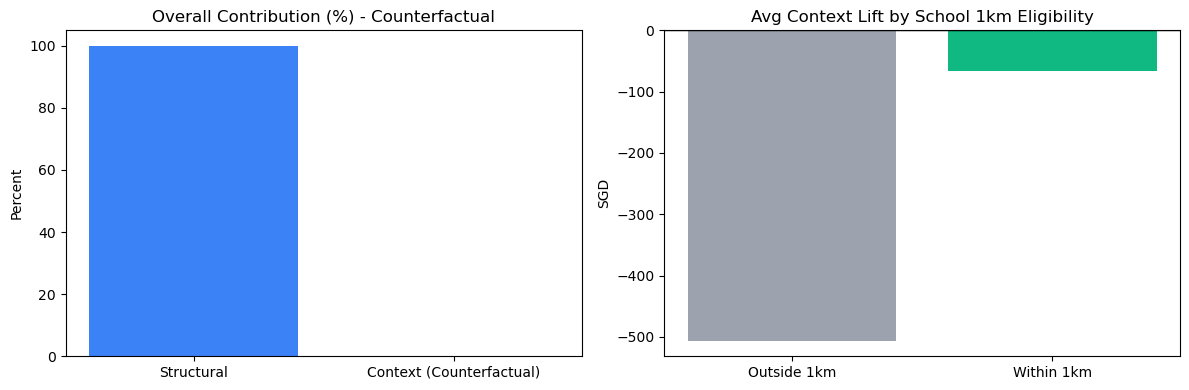

,within_1km_school,pct_structural_cf,pct_context_cf,ctx_lift
0,False,99.866091,0.133909,-506.327388
1,True,99.960742,0.039258,-66.026839


In [18]:
import matplotlib.pyplot as plt

# 更可解释的上下文贡献：用反事实方式计算
# baseline: 将上下文特征替换为训练集的中位数（等价于“普通区位”）
ctx_baseline = X_test_ctx.copy()
for c in ctx_baseline.columns:
    ctx_baseline[c] = X_train_ctx[c].median()

ctx_pred_actual = model_ctx.predict(X_test_ctx)
ctx_pred_baseline = model_ctx.predict(ctx_baseline)
ctx_lift = ctx_pred_actual - ctx_pred_baseline

plot_df = pd.DataFrame(
    {
        "pred_structural": test_struct_pred,
        "ctx_lift": ctx_lift,
        "within_1km_school": (model_df.loc[X_test.index, "nearest_school_dist_km"].reset_index(drop=True) <= 1.0),
    }
)
plot_df["pred_total_cf"] = plot_df["pred_structural"] + plot_df["ctx_lift"]

denom = np.abs(plot_df["pred_structural"]) + np.abs(plot_df["ctx_lift"]) + 1e-9
plot_df["pct_structural_cf"] = np.abs(plot_df["pred_structural"]) / denom * 100
plot_df["pct_context_cf"] = np.abs(plot_df["ctx_lift"]) / denom * 100

summary = (
    plot_df.groupby("within_1km_school")[["pct_structural_cf", "pct_context_cf", "ctx_lift"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 图1：反事实贡献占比
overall_struct = float(plot_df["pct_structural_cf"].mean())
overall_ctx = float(plot_df["pct_context_cf"].mean())
axes[0].bar(["Structural", "Context (Counterfactual)"], [overall_struct, overall_ctx], color=["#3b82f6", "#f59e0b"])
axes[0].set_title("Overall Contribution (%) - Counterfactual")
axes[0].set_ylabel("Percent")

# 图2：按 1km 学区资格看上下文抬升金额
x = ["Outside 1km", "Within 1km"]
lift_vals = [
    float(summary.loc[summary["within_1km_school"] == False, "ctx_lift"].iloc[0]) if (summary["within_1km_school"] == False).any() else np.nan,
    float(summary.loc[summary["within_1km_school"] == True, "ctx_lift"].iloc[0]) if (summary["within_1km_school"] == True).any() else np.nan,
]
axes[1].bar(x, lift_vals, color=["#9ca3af", "#10b981"])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Avg Context Lift by School 1km Eligibility")
axes[1].set_ylabel("SGD")

plt.tight_layout()
plt.show()

summary

In [19]:
# 诊断：上下文特征覆盖率与分布
ctx_diag_cols = [
    "dist_mrt_km",
    "dist_foodcourt_km",
    "num_malls_2km",
    "nearest_school_dist_km",
    "school_count_effective",
    "school_tier_effective",
]

diag = pd.DataFrame({
    "non_null_ratio": model_df[ctx_diag_cols].notna().mean(),
    "n_unique": model_df[ctx_diag_cols].nunique(),
    "std": model_df[ctx_diag_cols].std(),
})

diag

,non_null_ratio,n_unique,std
dist_mrt_km,1.0,295,0.089512
dist_foodcourt_km,1.0,295,0.036639
num_malls_2km,1.0,1,0.000000
nearest_school_dist_km,1.0,295,0.079552
school_count_effective,1.0,9,3.387201
school_tier_effective,1.0,4,0.082489


In [20]:
# 两个预测样例：1km 内 vs 1km 外，并输出各因素占比（特征消融局部解释）

def local_factor_breakdown(idx: int) -> pd.DataFrame:
    x_struct = X_test_struct.loc[idx].copy()
    x_ctx = X_test_ctx.loc[idx].copy()

    # 业务基线：学校相关特征默认 0（无学区优先）
    base_struct = X_train_struct.median(numeric_only=True)
    base_ctx = X_train_ctx.median(numeric_only=True)
    school_block_cols = [
        "school_admission_priority_weight",
        "school_count_effective",
        "school_tier_effective",
        "school_1km_completion_proxy",
    ]
    for c in school_block_cols:
        if c in base_ctx.index:
            base_ctx[c] = 0.0

    pred_struct = float(model_struct.predict(x_struct.to_frame().T)[0])
    pred_ctx = float(model_ctx.predict(x_ctx.to_frame().T)[0])
    pred_total = pred_struct + pred_ctx

    # 结构因子: 单因子消融
    struct_rows = []
    for f in structural_features:
        ablated = x_struct.copy()
        ablated[f] = base_struct[f]
        p_ablated = float(model_struct.predict(ablated.to_frame().T)[0])
        struct_rows.append({"factor": f, "group": "structural", "contribution_sgd": pred_struct - p_ablated})

    # 区位/学区因子: 单因子消融
    ctx_rows = []
    for f in context_features:
        ablated = x_ctx.copy()
        ablated[f] = base_ctx[f]
        p_ablated = float(model_ctx.predict(ablated.to_frame().T)[0])
        ctx_rows.append({"factor": f, "group": "context", "contribution_sgd": pred_ctx - p_ablated})

    out = pd.DataFrame(struct_rows + ctx_rows)
    total_abs = out["contribution_sgd"].abs().sum()
    out["contribution_pct"] = np.where(total_abs > 0, out["contribution_sgd"].abs() / total_abs * 100, 0.0)
    out = out.sort_values(["group", "contribution_pct"], ascending=[True, False]).reset_index(drop=True)
    out["pred_total"] = pred_total
    return out


test_view = model_df.loc[X_test.index, ["address", "town", "flat_type", "nearest_school_dist_km", "school_tier_effective"]].copy()
test_view["pred_price"] = test_pred
test_view["within_1km_school"] = test_view["nearest_school_dist_km"] <= 1.0

# 用反事实上下文抬升来挑样本，避免选到“上下文无影响”的边界点
ctx_baseline = X_test_ctx.copy()
for c in ctx_baseline.columns:
    ctx_baseline[c] = X_train_ctx[c].median()
for c in ["school_admission_priority_weight", "school_count_effective", "school_tier_effective", "school_1km_completion_proxy"]:
    if c in ctx_baseline.columns:
        ctx_baseline[c] = 0.0

ctx_lift = model_ctx.predict(X_test_ctx) - model_ctx.predict(ctx_baseline)
test_view["ctx_lift"] = ctx_lift

within_pool = test_view[(test_view["within_1km_school"]) & (test_view["school_tier_effective"] > 0)].copy()
outside_pool = test_view[(~test_view["within_1km_school"])].copy()

# within: 选 ctx_lift 绝对值较高样本；outside: 选接近中位的稳态样本
within_idx = within_pool["ctx_lift"].abs().idxmax() if len(within_pool) > 0 else test_view[test_view["within_1km_school"]].index[0]
outside_idx = (outside_pool["pred_price"] - outside_pool["pred_price"].median()).abs().idxmin()

example_within = test_view.loc[[within_idx]].copy()
example_outside = test_view.loc[[outside_idx]].copy()

print("Example A (within 1km)")
display(example_within)
display(local_factor_breakdown(within_idx))

print("Example B (outside 1km)")
display(example_outside)
display(local_factor_breakdown(outside_idx))

Example A (within 1km)


,address,town,flat_type,nearest_school_dist_km,school_tier_effective,pred_price,within_1km_school,ctx_lift
968628,309 SHUNFU RD,BISHAN,3 ROOM,0.907019,0.513579,544100.553763,True,3987.989767


,factor,group,contribution_sgd,contribution_pct,pred_total
0,school_name_target_mean,context,2485.573375,1.914250,545125.692203
1,dist_mrt_km,context,496.796691,0.382605,545125.692203
2,dist_foodcourt_km,context,491.185241,0.378284,545125.692203
3,school_tier_effective,context,241.958169,0.186343,545125.692203
4,num_malls_2km,context,0.000000,0.000000,545125.692203
5,nearest_school_dist_km,context,0.000000,0.000000,545125.692203
6,school_admission_priority_weight,context,0.000000,0.000000,545125.692203
7,school_count_effective,context,0.000000,0.000000,545125.692203
8,school_1km_completion_proxy,context,0.000000,0.000000,545125.692203
9,phase1_pressure_proxy,context,0.000000,0.000000,545125.692203


Example B (outside 1km)


,address,town,flat_type,nearest_school_dist_km,school_tier_effective,pred_price,within_1km_school,ctx_lift
968467,616 BEDOK RESERVOIR RD,BEDOK,3 ROOM,1.480001,0.282469,473852.231563,False,426.766939


,factor,group,contribution_sgd,contribution_pct,pred_total
0,dist_foodcourt_km,context,441.144475,0.248191,475315.289454
1,school_tier_effective,context,51.412266,0.028925,475315.289454
2,dist_mrt_km,context,0.000000,0.000000,475315.289454
3,num_malls_2km,context,0.000000,0.000000,475315.289454
4,nearest_school_dist_km,context,0.000000,0.000000,475315.289454
5,school_admission_priority_weight,context,0.000000,0.000000,475315.289454
6,school_count_effective,context,0.000000,0.000000,475315.289454
7,school_1km_completion_proxy,context,0.000000,0.000000,475315.289454
8,phase1_pressure_proxy,context,0.000000,0.000000,475315.289454
9,phase2a_pressure_proxy,context,0.000000,0.000000,475315.289454


School competition reference year: 2025


,example,address,pred_price,nearest_school,nearest_school_dist_km,competition_level,competition_percentile,demand_supply_ratio
0,Example A (within 1km),309 SHUNFU RD,544100.553763,Catholic High,0.907019,High,0.896648,1.000000
1,Example B (outside 1km),616 BEDOK RESERVOIR RD,473852.231563,St. Stephen’s,1.480001,Low,0.273743,0.351391


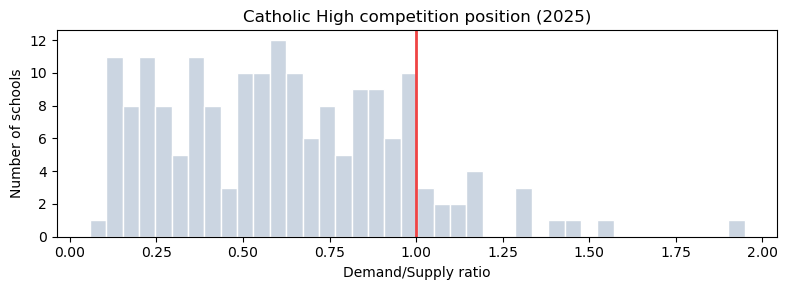

{'school_name': 'Catholic High', 'year': 2025, 'demand_supply_ratio': 1.0, 'competition_percentile': 0.8966, 'competition_level': 'High'}


In [21]:
# 为两个样例补充学校名 + 竞争程度，并提供按学校名查询的竞争度相对位置绘图
from pathlib import Path
import matplotlib.pyplot as plt


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1 = np.radians(lat1)
    p2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2.0) ** 2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


# 读取学校竞争数据（按最新可用年份）
school_feat_path = Path.cwd() / "data" / "interim" / "school_2016_onwards_features.csv"
school_geo_path = Path.cwd() / "data" / "interim" / "school_geocode.csv"
addr_geo_path = Path.cwd() / "data" / "interim" / "address_geocode.csv"

school_feat = pd.read_csv(school_feat_path)
school_geo = pd.read_csv(school_geo_path)
addr_geo = pd.read_csv(addr_geo_path)

school_feat["year"] = pd.to_numeric(school_feat["year"], errors="coerce")
school_feat["demand_supply_ratio"] = pd.to_numeric(school_feat["demand_supply_ratio"], errors="coerce")
latest_school_year = int(school_feat["year"].dropna().max())

school_latest = school_feat[school_feat["year"] == latest_school_year].copy()
school_latest = school_latest[["school_name", "demand_supply_ratio"]].dropna().drop_duplicates("school_name")

# 百分位越高表示竞争越激烈
school_latest["competition_percentile"] = school_latest["demand_supply_ratio"].rank(pct=True)
school_latest["competition_level"] = pd.cut(
    school_latest["competition_percentile"],
    bins=[0.0, 0.33, 0.67, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

school_meta = school_geo.merge(school_latest, on="school_name", how="left")
school_points = school_meta.dropna(subset=["school_lat", "school_lon"]).copy()


def nearest_school_for_address(addr: str) -> dict:
    rec = addr_geo[addr_geo["address"] == addr]
    if rec.empty:
        return {
            "nearest_school": np.nan,
            "school_dist_km": np.nan,
            "competition_level": np.nan,
            "competition_percentile": np.nan,
            "demand_supply_ratio": np.nan,
        }

    lat = float(rec.iloc[0]["lat"])
    lon = float(rec.iloc[0]["lon"])
    d = haversine_km(lat, lon, school_points["school_lat"].astype(float).values, school_points["school_lon"].astype(float).values)
    i = int(np.argmin(d))
    row = school_points.iloc[i]

    return {
        "nearest_school": row["school_name"],
        "school_dist_km": float(np.min(d)),
        "competition_level": row["competition_level"],
        "competition_percentile": float(row["competition_percentile"]) if pd.notna(row["competition_percentile"]) else np.nan,
        "demand_supply_ratio": float(row["demand_supply_ratio"]) if pd.notna(row["demand_supply_ratio"]) else np.nan,
    }


# 打印两个 example 的学校信息
example_rows = []
for tag, ex in [("Example A (within 1km)", example_within), ("Example B (outside 1km)", example_outside)]:
    addr = ex.iloc[0]["address"]
    info = nearest_school_for_address(addr)
    example_rows.append(
        {
            "example": tag,
            "address": addr,
            "pred_price": float(ex.iloc[0]["pred_price"]),
            "nearest_school": info["nearest_school"],
            "nearest_school_dist_km": info["school_dist_km"],
            "competition_level": info["competition_level"],
            "competition_percentile": info["competition_percentile"],
            "demand_supply_ratio": info["demand_supply_ratio"],
        }
    )

example_school_df = pd.DataFrame(example_rows)
print(f"School competition reference year: {latest_school_year}")
display(example_school_df)


def plot_school_competitiveness(school_name: str):
    """
    输入学校名，输出其竞争度在全体学校中的相对位置。
    """
    row = school_latest[school_latest["school_name"].str.lower() == school_name.lower()]
    if row.empty:
        print(f"School not found in year {latest_school_year}: {school_name}")
        return None

    r = row.iloc[0]
    ratio = float(r["demand_supply_ratio"])
    pct = float(r["competition_percentile"])
    lvl = str(r["competition_level"])

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(school_latest["demand_supply_ratio"].dropna(), bins=40, color="#cbd5e1", edgecolor="white")
    ax.axvline(ratio, color="#ef4444", linewidth=2)
    ax.set_title(f"{school_name} competition position ({latest_school_year})")
    ax.set_xlabel("Demand/Supply ratio")
    ax.set_ylabel("Number of schools")
    plt.tight_layout()
    plt.show()

    print(
        {
            "school_name": school_name,
            "year": latest_school_year,
            "demand_supply_ratio": round(ratio, 4),
            "competition_percentile": round(pct, 4),
            "competition_level": lvl,
        }
    )


# 示例调用：
if len(example_school_df) > 0 and pd.notna(example_school_df.iloc[0]["nearest_school"]):
    plot_school_competitiveness(str(example_school_df.iloc[0]["nearest_school"]))

In [22]:
# 探测 Nanyang 学校名匹配
school_latest[school_latest["school_name"].str.contains("Nanyang", case=False, na=False)].head(20)

,school_name,demand_supply_ratio,competition_percentile,competition_level
1736,Nanyang,0.893657,0.798883,High


In [25]:
# 全量样本中给出 Nanyang Primary School 相关房源 example（按最近距离兜底）

def local_factor_breakdown_from_row(row: pd.Series) -> pd.DataFrame:
    fit_struct_cols = X_train_struct.columns.tolist()
    fit_ctx_cols = X_train_ctx.columns.tolist()

    x_struct = row[fit_struct_cols].astype(float)
    x_ctx = row[fit_ctx_cols].astype(float)

    base_struct = X_train_struct.median(numeric_only=True)
    base_ctx = X_train_ctx.median(numeric_only=True)
    school_block_cols = [
        "school_admission_priority_weight",
        "school_count_effective",
        "school_tier_effective",
        "school_1km_completion_proxy",
    ]
    for c in school_block_cols:
        if c in base_ctx.index:
            base_ctx[c] = 0.0

    pred_struct = float(model_struct.predict(x_struct.to_frame().T[fit_struct_cols])[0])
    pred_ctx = float(model_ctx.predict(x_ctx.to_frame().T[fit_ctx_cols])[0])
    pred_total = pred_struct + pred_ctx

    rows = []
    for f in fit_struct_cols:
        ablated = x_struct.copy()
        ablated[f] = base_struct[f]
        p_ablated = float(model_struct.predict(ablated.to_frame().T[fit_struct_cols])[0])
        rows.append({"factor": f, "group": "structural", "contribution_sgd": pred_struct - p_ablated})

    for f in fit_ctx_cols:
        ablated = x_ctx.copy()
        ablated[f] = base_ctx[f]
        p_ablated = float(model_ctx.predict(ablated.to_frame().T[fit_ctx_cols])[0])
        rows.append({"factor": f, "group": "context", "contribution_sgd": pred_ctx - p_ablated})

    out = pd.DataFrame(rows)
    total_abs = out["contribution_sgd"].abs().sum()
    out["contribution_pct"] = np.where(total_abs > 0, out["contribution_sgd"].abs() / total_abs * 100, 0.0)
    out = out.sort_values(["group", "contribution_pct"], ascending=[True, False]).reset_index(drop=True)
    out["pred_total"] = pred_total
    return out


# OneMap 查询到 Nanyang Primary School 坐标（Kings Road）
nanyang_lat = 1.320847499045325
nanyang_lon = 103.807750155296

addr_lat_col = "latitude" if "latitude" in addr_geo.columns else "lat"
addr_lon_col = "longitude" if "longitude" in addr_geo.columns else "lon"
fit_struct_cols = X_train_struct.columns.tolist()
fit_ctx_cols = X_train_ctx.columns.tolist()

meta_cols = [c for c in ["address", "town", "flat_type", "year"] if c in model_df.columns]
select_cols = []
for c in meta_cols + fit_struct_cols + fit_ctx_cols:
    if c not in select_cols:
        select_cols.append(c)

cand = model_df[select_cols].copy()

# Avoid duplicate lat/lon columns when model_df already contains coordinates.
if addr_lat_col not in cand.columns or addr_lon_col not in cand.columns:
    cand = cand.merge(
        addr_geo[["address", addr_lat_col, addr_lon_col]], on="address", how="left"
    )

# Normalize possible suffix columns created by merges.
if addr_lat_col not in cand.columns:
    for alt in [f"{addr_lat_col}_x", f"{addr_lat_col}_y", "lat", "latitude"]:
        if alt in cand.columns:
            cand[addr_lat_col] = cand[alt]
            break
if addr_lon_col not in cand.columns:
    for alt in [f"{addr_lon_col}_x", f"{addr_lon_col}_y", "lon", "longitude"]:
        if alt in cand.columns:
            cand[addr_lon_col] = cand[alt]
            break

cand = cand.dropna(subset=[addr_lat_col, addr_lon_col]).copy()

R = 6371.0
lat1 = np.radians(cand[addr_lat_col].astype(float).values)
lon1 = np.radians(cand[addr_lon_col].astype(float).values)
lat2 = np.radians(nanyang_lat)
lon2 = np.radians(nanyang_lon)

dlat = lat1 - lat2
dlon = lon1 - lon2
a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
cand["dist_to_nanyang_km"] = 2 * R * np.arcsin(np.sqrt(a))

# 选择离 Nanyang 最近的一批地址，再取最近年份中位预测附近样本，避免极端值
top = cand.nsmallest(300, "dist_to_nanyang_km").copy()
top["pred_tmp"] = model_struct.predict(top[fit_struct_cols]) + model_ctx.predict(top[fit_ctx_cols])
latest_y = int(top["year"].max()) if "year" in top.columns else None
if latest_y is not None:
    top_y = top[top["year"] == latest_y].copy()
    if top_y.empty:
        top_y = top.copy()
else:
    top_y = top.copy()

pick_idx = (top_y["pred_tmp"] - top_y["pred_tmp"].median()).abs().idxmin()
pick_row = top_y.loc[pick_idx]

# 学校竞争信息
nanyang_comp = school_latest[school_latest["school_name"].astype(str).str.lower().eq("nanyang")]
comp_ratio = float(nanyang_comp["demand_supply_ratio"].iloc[0]) if not nanyang_comp.empty else np.nan
comp_level = nanyang_comp["competition_level"].iloc[0] if not nanyang_comp.empty else np.nan

print("Example C (Nanyang Primary School reference)")
display(pd.DataFrame([{
    "address": pick_row["address"],
    "town": pick_row.get("town", np.nan),
    "flat_type": pick_row.get("flat_type", np.nan),
    "year": pick_row.get("year", np.nan),
    "pred_price": float(pick_row["pred_tmp"]),
    "distance_to_nanyang_km": float(pick_row["dist_to_nanyang_km"]),
    "school_name": "Nanyang Primary School",
    "competition_level": comp_level,
    "demand_supply_ratio": comp_ratio,
}]))

breakdown_c = local_factor_breakdown_from_row(pick_row)
display(breakdown_c)

school_block = [
    "school_admission_priority_weight",
    "school_count_effective",
    "school_tier_effective",
    "school_1km_completion_proxy",
]
school_block = [f for f in school_block if f in breakdown_c["factor"].tolist()]

school_block_sgd = float(breakdown_c.loc[breakdown_c["factor"].isin(school_block), "contribution_sgd"].sum())
total_abs = float(breakdown_c["contribution_sgd"].abs().sum())
school_block_pct = float(abs(school_block_sgd) / total_abs * 100) if total_abs > 0 else np.nan

print("Nanyang example school block contribution")
display(pd.DataFrame([{
    "school_block_contribution_sgd": school_block_sgd,
    "school_block_contribution_pct_of_total_abs": school_block_pct,
}]))

Example C (Nanyang Primary School reference)


,address,town,flat_type,year,pred_price,distance_to_nanyang_km,school_name,competition_level,demand_supply_ratio
0,4 QUEEN'S RD,BUKIT TIMAH,3 ROOM,2026,447772.011711,0.22675,Nanyang Primary School,High,0.893657


,factor,group,contribution_sgd,contribution_pct,pred_total
0,school_name_target_mean,context,230.991900,0.099346,447772.011711
1,school_count_effective,context,63.502969,0.027312,447772.011711
2,dist_mrt_km,context,0.000000,0.000000,447772.011711
3,dist_foodcourt_km,context,0.000000,0.000000,447772.011711
4,num_malls_2km,context,0.000000,0.000000,447772.011711
5,nearest_school_dist_km,context,0.000000,0.000000,447772.011711
6,school_admission_priority_weight,context,0.000000,0.000000,447772.011711
7,school_tier_effective,context,0.000000,0.000000,447772.011711
8,school_1km_completion_proxy,context,0.000000,0.000000,447772.011711
9,phase1_pressure_proxy,context,0.000000,0.000000,447772.011711


Nanyang example school block contribution


,school_block_contribution_sgd,school_block_contribution_pct_of_total_abs
0,63.502969,0.027312


In [26]:
# 解释 Example C：单特征贡献 vs 学校整体联合贡献
fit_ctx_cols = X_train_ctx.columns.tolist()

school_feature_block = [
    c
    for c in [
        "nearest_school_dist_km",
        "school_admission_priority_weight",
        "school_count_effective",
        "school_tier_effective",
        "school_1km_completion_proxy",
    ]
    if c in fit_ctx_cols
]

x_ctx_pick = pick_row[fit_ctx_cols].astype(float).copy()
base_ctx_pick = X_train_ctx.median(numeric_only=True).copy()
for c in ["school_admission_priority_weight", "school_count_effective", "school_tier_effective", "school_1km_completion_proxy"]:
    if c in base_ctx_pick.index:
        base_ctx_pick[c] = 0.0

pred_ctx_actual = float(model_ctx.predict(x_ctx_pick.to_frame().T[fit_ctx_cols])[0])

ablated_all_school = x_ctx_pick.copy()
for c in school_feature_block:
    ablated_all_school[c] = base_ctx_pick[c]
pred_ctx_without_school_block = float(model_ctx.predict(ablated_all_school.to_frame().T[fit_ctx_cols])[0])

breakdown_now = local_factor_breakdown_from_row(pick_row).set_index("factor")

explain_df = pd.DataFrame([
    {
        "metric": "context_pred_actual",
        "value": pred_ctx_actual,
    },
    {
        "metric": "context_pred_without_school_block",
        "value": pred_ctx_without_school_block,
    },
    {
        "metric": "combined_school_block_contribution",
        "value": pred_ctx_actual - pred_ctx_without_school_block,
    },
    {
        "metric": "single_feature_school_tier_effective",
        "value": float(breakdown_now.loc["school_tier_effective", "contribution_sgd"]) if "school_tier_effective" in breakdown_now.index else np.nan,
    },
    {
        "metric": "single_feature_school_1km_completion_proxy",
        "value": float(breakdown_now.loc["school_1km_completion_proxy", "contribution_sgd"]) if "school_1km_completion_proxy" in breakdown_now.index else np.nan,
    },
])

explain_df

,metric,value
0,context_pred_actual,285.492543
1,context_pred_without_school_block,221.989573
2,combined_school_block_contribution,63.502969
3,single_feature_school_tier_effective,0.000000
4,single_feature_school_1km_completion_proxy,0.000000


In [27]:
# 汇总输出：Nanyang 样例各因素占比（按贡献绝对值排序）
summary_cols = ["factor", "group", "contribution_sgd", "contribution_pct"]
nanyang_factor_pct = breakdown_c[summary_cols].copy().sort_values("contribution_pct", ascending=False).reset_index(drop=True)

# 学校特征组整体占比
school_block = [
    "school_admission_priority_weight",
    "school_count_effective",
    "school_tier_effective",
    "school_1km_completion_proxy",
    "nearest_school_dist_km",
]
school_block = [f for f in school_block if f in nanyang_factor_pct["factor"].tolist()]

school_block_abs = float(nanyang_factor_pct.loc[nanyang_factor_pct["factor"].isin(school_block), "contribution_sgd"].abs().sum())
all_abs = float(nanyang_factor_pct["contribution_sgd"].abs().sum())
school_block_abs_pct = float(school_block_abs / all_abs * 100) if all_abs > 0 else np.nan

print("Nanyang example - factor contribution table")
display(nanyang_factor_pct)

print("Nanyang example - school block (absolute share)")
display(pd.DataFrame([{
    "school_block_abs_contribution_sgd": school_block_abs,
    "school_block_abs_share_pct": school_block_abs_pct,
}]))

Nanyang example - factor contribution table


,factor,group,contribution_sgd,contribution_pct
0,af_price_anchor,structural,-170183.230752,73.193186
1,year,structural,23784.119258,10.229183
2,address_target_mean,structural,-11174.558586,4.806005
3,level_mid,structural,6568.293807,2.824922
4,lease_years_left,structural,-5565.780517,2.393756
5,prev_same_block_psm,structural,-3992.564477,1.717140
6,project_prev_mean_price,structural,-2053.059471,0.882989
7,town_flat_type_target_mean,structural,-1757.192512,0.755741
8,af_psm_anchor,structural,-1451.613162,0.624316
9,dist_jurong_lake_district_km,structural,944.899366,0.406387


Nanyang example - school block (absolute share)


,school_block_abs_contribution_sgd,school_block_abs_share_pct
0,63.502969,0.027312


In [28]:
# 同步 school identity 编码到 model_df（供后续全量对比单元使用）
if "school_name_target_mean" not in model_df.columns:
    global_mean_tmp = float(train_df[target_col].mean())
    school_mean_map_tmp = train_df.groupby("nearest_school_name")[target_col].mean()
    model_df["school_name_target_mean"] = model_df["nearest_school_name"].map(school_mean_map_tmp).fillna(global_mean_tmp)

# 防御性填充，避免后续预测列缺失
model_df["school_name_target_mean"] = pd.to_numeric(model_df["school_name_target_mean"], errors="coerce")
model_df["school_name_target_mean"] = model_df["school_name_target_mean"].fillna(float(train_df[target_col].mean()))

print("school_name_target_mean synced to model_df")

school_name_target_mean synced to model_df


In [29]:
# 对比案例：Woodlands HDB vs Clementi 名校学区 HDB

def predict_total_from_row(row: pd.Series) -> float:
    fit_struct_cols = X_train_struct.columns.tolist()
    fit_ctx_cols = X_train_ctx.columns.tolist()
    struct_pred = float(model_struct.predict(row[fit_struct_cols].astype(float).to_frame().T[fit_struct_cols])[0])
    ctx_pred = float(model_ctx.predict(row[fit_ctx_cols].astype(float).to_frame().T[fit_ctx_cols])[0])
    return struct_pred + ctx_pred


def predict_ctx_from_series(ctx_series: pd.Series) -> float:
    fit_ctx_cols = X_train_ctx.columns.tolist()
    return float(model_ctx.predict(ctx_series[fit_ctx_cols].astype(float).to_frame().T[fit_ctx_cols])[0])


def add_school_meta(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in frame.iterrows():
        info = nearest_school_for_address(row["address"])
        rows.append({
            "nearest_school": info.get("nearest_school"),
            "school_dist_km_check": info.get("school_dist_km"),
            "competition_level_check": info.get("competition_level"),
            "competition_percentile_check": info.get("competition_percentile"),
            "demand_supply_ratio_check": info.get("demand_supply_ratio"),
        })
    return pd.concat([frame.reset_index(drop=True), pd.DataFrame(rows)], axis=1)


def priority_weight_from_distance(dist_km: float) -> float:
    if pd.isna(dist_km):
        return 0.15
    if dist_km <= 1.0:
        return 1.0
    if dist_km <= 2.0:
        return 0.55
    return 0.15


def build_actual_school_block(row: pd.Series) -> pd.Series:
    out = row[X_train_ctx.columns].astype(float).copy()
    actual_dist = float(row["school_dist_km_check"])
    actual_pct = float(row["competition_percentile_check"])
    actual_weight = priority_weight_from_distance(actual_dist)

    current_weight = float(row.get("school_admission_priority_weight", actual_weight)) if pd.notna(row.get("school_admission_priority_weight", actual_weight)) else actual_weight
    raw_school_count = float(row.get("school_count_effective", 0.0)) / current_weight if current_weight > 0 else float(row.get("school_count_effective", 0.0))

    if "nearest_school_dist_km" in out.index:
        out["nearest_school_dist_km"] = actual_dist
    if "school_admission_priority_weight" in out.index:
        out["school_admission_priority_weight"] = actual_weight
    if "school_count_effective" in out.index:
        out["school_count_effective"] = raw_school_count * actual_weight
    if "school_tier_effective" in out.index:
        out["school_tier_effective"] = actual_pct * actual_weight
    if "school_1km_completion_proxy" in out.index:
        out["school_1km_completion_proxy"] = actual_pct if actual_dist <= 1.0 else 0.0
    return out


meta_compare_cols = ["address", "town", "flat_type", "year"]
fit_struct_cols = X_train_struct.columns.tolist()
fit_ctx_cols = X_train_ctx.columns.tolist()
compare_cols = []
for col in meta_compare_cols + fit_struct_cols + fit_ctx_cols:
    if col not in compare_cols:
        compare_cols.append(col)

compare_pool = model_df[compare_cols].copy()
compare_pool["pred_price"] = model_struct.predict(compare_pool[fit_struct_cols]) + model_ctx.predict(compare_pool[fit_ctx_cols])

latest_compare_year = int(compare_pool["year"].max())
compare_pool = compare_pool[compare_pool["year"] == latest_compare_year].copy()

candidate_towns = compare_pool[compare_pool["town"].astype(str).str.upper().isin(["CLEMENTI", "WOODLANDS"])].copy()
candidate_towns = add_school_meta(candidate_towns)

# Clementi: within 1km, strongest actual school competitiveness, then pick median-ish price
clementi_actual_pool = candidate_towns[
    (candidate_towns["town"].astype(str).str.upper() == "CLEMENTI")
    & (candidate_towns["school_dist_km_check"] <= 1.0)
].copy()
clementi_actual_pool = clementi_actual_pool.sort_values(["competition_percentile_check", "pred_price"], ascending=[False, True]).copy()

# Prefer 4-room/5-room examples for easier comparison
preferred_flat_types = ["4 ROOM", "5 ROOM"]
clementi_pref = clementi_actual_pool[clementi_actual_pool["flat_type"].isin(preferred_flat_types)].copy()
if not clementi_pref.empty:
    clementi_actual_pool = clementi_pref

clementi_pick_idx = (clementi_actual_pool["pred_price"] - clementi_actual_pool["pred_price"].median()).abs().idxmin()
clementi_row = clementi_actual_pool.loc[clementi_pick_idx].copy()

# Woodlands: lower actual school competitiveness, but match structure + non-school context
woodlands_actual_pool = candidate_towns[
    (candidate_towns["town"].astype(str).str.upper() == "WOODLANDS")
    & (candidate_towns["flat_type"] == clementi_row["flat_type"])
].copy()
if woodlands_actual_pool.empty:
    woodlands_actual_pool = candidate_towns[candidate_towns["town"].astype(str).str.upper() == "WOODLANDS"].copy()

# Bias selection toward lower-competition school zones in Woodlands
woodlands_actual_pool["competition_bias"] = woodlands_actual_pool["competition_percentile_check"].fillna(0)
match_features = [
    "year",
    "level_mid",
    "lease_years_left",
    "floor_area_sqm",
    "room_count",
    "dist_mrt_km",
    "dist_foodcourt_km",
    "num_malls_2km",
]
match_scale = candidate_towns[match_features].std().replace(0, 1).fillna(1)
match_delta = (woodlands_actual_pool[match_features] - clementi_row[match_features]).abs().div(match_scale, axis=1)
woodlands_actual_pool["match_score"] = match_delta.sum(axis=1) + woodlands_actual_pool["competition_bias"] * 2.0
woodlands_pick_idx = woodlands_actual_pool["match_score"].idxmin()
woodlands_row = woodlands_actual_pool.loc[woodlands_pick_idx].copy()

pair_df = pd.DataFrame([clementi_row, woodlands_row]).reset_index(drop=True)

# Build school-block comparison using actual nearest-school competition + actual distance bucket
clementi_ctx_actual = build_actual_school_block(clementi_row)
woodlands_ctx_actual = build_actual_school_block(woodlands_row)

clementi_ctx_with_woodlands_school = clementi_ctx_actual.copy()
for c in [col for col in ["nearest_school_dist_km", "school_admission_priority_weight", "school_count_effective", "school_tier_effective", "school_1km_completion_proxy"] if col in clementi_ctx_with_woodlands_school.index]:
    clementi_ctx_with_woodlands_school[c] = woodlands_ctx_actual[c]

clementi_struct_pred = float(model_struct.predict(clementi_row[X_train_struct.columns].astype(float).to_frame().T[X_train_struct.columns])[0])
woodlands_struct_pred = float(model_struct.predict(woodlands_row[X_train_struct.columns].astype(float).to_frame().T[X_train_struct.columns])[0])

clementi_ctx_pred = predict_ctx_from_series(clementi_ctx_actual)
woodlands_ctx_pred = predict_ctx_from_series(woodlands_ctx_actual)
clementi_ctx_with_woodlands_school_pred = predict_ctx_from_series(clementi_ctx_with_woodlands_school)

clementi_total_pred = clementi_struct_pred + clementi_ctx_pred
woodlands_total_pred = woodlands_struct_pred + woodlands_ctx_pred

price_gap_total = clementi_total_pred - woodlands_total_pred
price_gap_structural = clementi_struct_pred - woodlands_struct_pred
price_gap_non_school_context = clementi_ctx_with_woodlands_school_pred - woodlands_ctx_pred
price_gap_school_only = clementi_ctx_pred - clementi_ctx_with_woodlands_school_pred

comparison_summary = pd.DataFrame([
    {
        "component": "total_price_gap_clementi_minus_woodlands",
        "sgd": price_gap_total,
        "share_of_total_gap_pct": 100.0,
    },
    {
        "component": "structural_gap",
        "sgd": price_gap_structural,
        "share_of_total_gap_pct": price_gap_structural / price_gap_total * 100 if price_gap_total != 0 else np.nan,
    },
    {
        "component": "non_school_context_gap",
        "sgd": price_gap_non_school_context,
        "share_of_total_gap_pct": price_gap_non_school_context / price_gap_total * 100 if price_gap_total != 0 else np.nan,
    },
    {
        "component": "school_only_gap_on_clementi_base",
        "sgd": price_gap_school_only,
        "share_of_total_gap_pct": price_gap_school_only / price_gap_total * 100 if price_gap_total != 0 else np.nan,
    },
])

feature_compare = pd.DataFrame([
    {
        "feature": col,
        "clementi": clementi_row[col] if col in clementi_row.index else np.nan,
        "woodlands": woodlands_row[col] if col in woodlands_row.index else np.nan,
        "difference": (
            clementi_row[col] - woodlands_row[col]
            if col in clementi_row.index and col in woodlands_row.index and pd.api.types.is_number(clementi_row[col]) and pd.api.types.is_number(woodlands_row[col])
            else np.nan
        ),
    }
    for col in ["address", "town", "flat_type", "year", "floor_area_sqm", "room_count", "level_mid", "lease_years_left", "dist_mrt_km", "dist_foodcourt_km", "num_malls_2km", "pred_price", "nearest_school", "school_dist_km_check", "competition_level_check", "competition_percentile_check", "demand_supply_ratio_check"]
])

print(f"Matched comparison year: {latest_compare_year}")
print("Matched pair overview")
display(pair_df[["address", "town", "flat_type", "year", "pred_price", "nearest_school", "school_dist_km_check", "competition_level_check", "competition_percentile_check", "demand_supply_ratio_check"]])

print("Matched feature comparison")
display(feature_compare)

print("Price gap decomposition using actual school competitiveness + MOE distance priority")
display(comparison_summary)

Matched comparison year: 2026
Matched pair overview


,address,town,flat_type,year,pred_price,nearest_school,school_dist_km_check,competition_level_check,competition_percentile_check,demand_supply_ratio_check
0,329 CLEMENTI AVE 2,CLEMENTI,4 ROOM,2026,700359.165527,Pei Tong,0.400245,Low,0.078212,0.156192
1,26 MARSILING DR,WOODLANDS,4 ROOM,2026,482498.834167,Marsiling,0.681993,Medium,0.480447,0.575472


Matched feature comparison


,feature,clementi,woodlands,difference
0,address,329 CLEMENTI AVE 2,26 MARSILING DR,NaN
1,town,CLEMENTI,WOODLANDS,NaN
2,flat_type,4 ROOM,4 ROOM,NaN
3,year,2026,2026,0.000000
4,floor_area_sqm,92.0,91.0,1.000000
5,room_count,4.0,4.0,0.000000
6,level_mid,8.0,8.0,0.000000
7,lease_years_left,51,50,1.000000
8,dist_mrt_km,0.878822,0.878822,0.000000
9,dist_foodcourt_km,0.267752,0.267752,0.000000


Price gap decomposition using actual school competitiveness + MOE distance priority


,component,sgd,share_of_total_gap_pct
0,total_price_gap_clementi_minus_woodlands,217958.896034,100.000000
1,structural_gap,216412.546750,99.290532
2,non_school_context_gap,1407.145354,0.645601
3,school_only_gap_on_clementi_base,139.203929,0.063867


In [30]:
# 辅助查看：Clementi / Woodlands 的学校竞争度候选
candidate_towns = compare_pool[compare_pool["town"].astype(str).str.upper().isin(["CLEMENTI", "WOODLANDS"])].copy()
candidate_towns = add_school_meta(candidate_towns)

print("Top Clementi school-zone candidates by actual competition")
display(
    candidate_towns[
        (candidate_towns["town"].astype(str).str.upper() == "CLEMENTI")
        & (candidate_towns["school_dist_km_check"] <= 1.0)
    ][["address", "flat_type", "pred_price", "nearest_school", "school_dist_km_check", "competition_percentile_check", "demand_supply_ratio_check"]]
    .sort_values(["competition_percentile_check", "school_dist_km_check"], ascending=[False, True])
    .head(15)
)

print("Top Woodlands candidates by actual competition")
display(
    candidate_towns[
        candidate_towns["town"].astype(str).str.upper() == "WOODLANDS"
    ][["address", "flat_type", "pred_price", "nearest_school", "school_dist_km_check", "competition_percentile_check", "demand_supply_ratio_check"]]
    .sort_values(["competition_percentile_check", "school_dist_km_check"], ascending=[True, True])
    .head(15)
)

Top Clementi school-zone candidates by actual competition


,address,flat_type,pred_price,nearest_school,school_dist_km_check,competition_percentile_check,demand_supply_ratio_check
173,507 WEST COAST DR,3 ROOM,396538.583872,Qifa,0.469632,0.491620,0.581395
174,507 WEST COAST DR,4 ROOM,501221.083802,Qifa,0.469632,0.491620,0.581395
180,511 WEST COAST DR,4 ROOM,507379.315799,Qifa,0.522024,0.491620,0.581395
181,511 WEST COAST DR,4 ROOM,517980.700263,Qifa,0.522024,0.491620,0.581395
176,510 WEST COAST DR,3 ROOM,396001.701420,Qifa,0.526213,0.491620,0.581395
177,510 WEST COAST DR,3 ROOM,389833.067336,Qifa,0.526213,0.491620,0.581395
148,434 CLEMENTI AVE 3,3 ROOM,408437.125453,Qifa,0.560785,0.491620,0.581395
147,430 CLEMENTI AVE 3,3 ROOM,426941.356447,Qifa,0.645865,0.491620,0.581395
285,701 WEST COAST RD,3 ROOM,401284.420338,Qifa,0.811456,0.491620,0.581395
286,702 WEST COAST RD,3 ROOM,377563.298945,Qifa,0.823515,0.491620,0.581395


Top Woodlands candidates by actual competition


,address,flat_type,pred_price,nearest_school,school_dist_km_check,competition_percentile_check,demand_supply_ratio_check
380,874 WOODLANDS ST 82,4 ROOM,5.846958e+05,Qihua,0.167043,0.184358,0.263617
366,816 WOODLANDS ST 82,EXECUTIVE,1.195987e+06,Qihua,0.174082,0.184358,0.263617
368,824 WOODLANDS ST 81,5 ROOM,6.533103e+05,Qihua,0.314271,0.184358,0.263617
369,829 WOODLANDS ST 83,EXECUTIVE,7.918657e+05,Qihua,0.355461,0.184358,0.263617
371,842 WOODLANDS ST 82,4 ROOM,4.966088e+05,Qihua,0.462327,0.184358,0.263617
141,420 WOODLANDS ST 41,EXECUTIVE,1.001300e+06,Fuchun,0.163739,0.268156,0.349614
28,165 WOODLANDS ST 13,5 ROOM,6.327354e+05,Fuchun,0.376544,0.268156,0.349614
29,168 WOODLANDS ST 11,4 ROOM,5.352020e+05,Fuchun,0.429735,0.268156,0.349614
95,329 WOODLANDS ST 32,4 ROOM,4.862429e+05,Fuchun,0.447806,0.268156,0.349614
32,173 WOODLANDS ST 13,4 ROOM,5.066834e+05,Fuchun,0.499375,0.268156,0.349614


In [31]:
# 纯反事实：固定同一套 Woodlands 3 ROOM HDB，只替换学校条件（名校 vs 非名校）

def build_school_counterfactual_from_name(base_row: pd.Series, school_name: str, target_distance_km: float = 0.5) -> pd.Series:
    school_row = school_latest[school_latest["school_name"].astype(str).str.lower() == school_name.lower()]
    if school_row.empty:
        raise ValueError(f"School not found: {school_name}")

    school_pct = float(school_row.iloc[0]["competition_percentile"])
    school_ratio = float(school_row.iloc[0]["demand_supply_ratio"])
    school_level = str(school_row.iloc[0]["competition_level"])

    cf_ctx = base_row[X_train_ctx.columns].astype(float).copy()
    raw_school_count = float(base_row.get("school_count_effective", 0.0)) / float(base_row.get("school_admission_priority_weight", 1.0)) if float(base_row.get("school_admission_priority_weight", 1.0)) > 0 else 0.0
    priority_weight = priority_weight_from_distance(target_distance_km)

    if "nearest_school_dist_km" in cf_ctx.index:
        cf_ctx["nearest_school_dist_km"] = target_distance_km
    if "school_admission_priority_weight" in cf_ctx.index:
        cf_ctx["school_admission_priority_weight"] = priority_weight
    if "school_count_effective" in cf_ctx.index:
        cf_ctx["school_count_effective"] = raw_school_count * priority_weight
    if "school_tier_effective" in cf_ctx.index:
        cf_ctx["school_tier_effective"] = school_pct * priority_weight
    if "school_1km_completion_proxy" in cf_ctx.index:
        cf_ctx["school_1km_completion_proxy"] = school_pct if target_distance_km <= 1.0 else 0.0

    # phase pressure proxies scale with school competitiveness percentile
    for c in ["phase1_pressure_proxy", "phase2a_pressure_proxy", "phase2b_pressure_proxy", "phase2c_pressure_proxy", "phase2cs_pressure_proxy"]:
        if c in cf_ctx.index:
            cf_ctx[c] = school_pct

    if "school_name_target_mean" in cf_ctx.index:
        if "school_name_target_mean" in train_df.columns:
            school_te = train_df.loc[train_df["nearest_school_name"].astype(str).str.lower() == school_name.lower(), target_col].mean()
            cf_ctx["school_name_target_mean"] = float(school_te) if pd.notna(school_te) else float(train_df[target_col].mean())

    return pd.Series({
        "school_name": school_name,
        "target_distance_km": target_distance_km,
        "competition_percentile": school_pct,
        "competition_level": school_level,
        "demand_supply_ratio": school_ratio,
        "ctx_pred": predict_ctx_from_series(cf_ctx),
    })


# 选择一套 Woodlands 3 ROOM 且学校信息完整的样本做底稿
woodlands_base_pool = candidate_towns[
    (candidate_towns["town"].astype(str).str.upper() == "WOODLANDS")
    & (candidate_towns["flat_type"].astype(str).str.contains("3 ROOM", case=False, na=False))
    & (candidate_towns["school_dist_km_check"].notna())
    & (candidate_towns["competition_percentile_check"].notna())
] .copy()

if woodlands_base_pool.empty:
    raise ValueError("No Woodlands 3 ROOM sample with complete school metadata found in current model dataset.")

woodlands_base_pool = woodlands_base_pool.sort_values(["competition_percentile_check", "pred_price"], ascending=[True, True]).copy()
woodlands_base_idx = (woodlands_base_pool["pred_price"] - woodlands_base_pool["pred_price"].median()).abs().idxmin()
woodlands_base = woodlands_base_pool.loc[woodlands_base_idx].copy()

base_struct_pred = float(model_struct.predict(woodlands_base[X_train_struct.columns].astype(float).to_frame().T[X_train_struct.columns])[0])
base_ctx_actual = build_actual_school_block(woodlands_base)
base_ctx_pred = predict_ctx_from_series(base_ctx_actual)
base_total_pred = base_struct_pred + base_ctx_pred

scenarios = []
scenarios.append({
    "scenario": "Original non-elite school zone",
    "school_name": woodlands_base["nearest_school"],
    "distance_km": float(woodlands_base["school_dist_km_check"]),
    "competition_percentile": float(woodlands_base["competition_percentile_check"]),
    "competition_level": str(woodlands_base["competition_level_check"]),
    "pred_price": base_total_pred,
    "price_lift_vs_base": 0.0,
})

# 名校学区：Nanyang within 1km
elite_cf = build_school_counterfactual_from_name(woodlands_base, "Nanyang", target_distance_km=0.23)
scenarios.append({
    "scenario": "Same 3 ROOM + elite school zone (Nanyang within 1km)",
    "school_name": elite_cf["school_name"],
    "distance_km": float(elite_cf["target_distance_km"]),
    "competition_percentile": float(elite_cf["competition_percentile"]),
    "competition_level": str(elite_cf["competition_level"]),
    "pred_price": base_struct_pred + float(elite_cf["ctx_pred"]),
    "price_lift_vs_base": float(elite_cf["ctx_pred"] - base_ctx_pred),
})

cf_summary = pd.DataFrame(scenarios)

print("Woodlands base 3 ROOM flat for pure counterfactual")
display(pd.DataFrame([{
    "address": woodlands_base["address"],
    "town": woodlands_base["town"],
    "flat_type": woodlands_base["flat_type"],
    "year": woodlands_base["year"],
    "floor_area_sqm": woodlands_base["floor_area_sqm"],
    "room_count": woodlands_base["room_count"],
    "level_mid": woodlands_base["level_mid"],
    "lease_years_left": woodlands_base["lease_years_left"],
    "dist_mrt_km": woodlands_base["dist_mrt_km"],
    "dist_foodcourt_km": woodlands_base["dist_foodcourt_km"],
    "num_malls_2km": woodlands_base["num_malls_2km"],
    "current_nearest_school": woodlands_base["nearest_school"],
    "current_school_dist_km": woodlands_base["school_dist_km_check"],
    "current_competition_percentile": woodlands_base["competition_percentile_check"],
    "current_pred_price": base_total_pred,
}]))

print("3 ROOM pure school-swap counterfactual (non-elite vs elite)")
display(cf_summary)

Woodlands base 3 ROOM flat for pure counterfactual


,address,town,flat_type,year,floor_area_sqm,room_count,level_mid,lease_years_left,dist_mrt_km,dist_foodcourt_km,num_malls_2km,current_nearest_school,current_school_dist_km,current_competition_percentile,current_pred_price
0,203 MARSILING DR,WOODLANDS,3 ROOM,2026,68.0,3.0,8.0,54,0.878822,0.267752,0.0,Marsiling,0.553468,0.480447,369196.594995


3 ROOM pure school-swap counterfactual (non-elite vs elite)


,scenario,school_name,distance_km,competition_percentile,competition_level,pred_price,price_lift_vs_base
0,Original non-elite school zone,Marsiling,0.553468,0.480447,Medium,369196.594995,0.000000
1,Same 3 ROOM + elite school zone (Nanyang withi...,Nanyang,0.230000,0.798883,High,371011.470418,1814.875423


## 方案架构（落地版）

建议分 4 层：

1. Data Ingestion：data.gov + Google Places + sgschooling 抓取与缓存。
2. Feature Store：按 `address` 聚合结构化特征与区位特征，产出训练集。
3. Modeling：双模型（Structural + Context Residual）并输出预测与贡献占比。
4. Serving & Search：根据买家权重实时排序候选房源，展示价格构成与推荐原因。

推荐在线接口：

- `POST /predict`：输入单套房屋特征，返回预测价与贡献分解。
- `POST /rank`：输入买家偏好权重与约束，返回排序结果。
- `GET /feature-attribution/{listing_id}`：返回该房源的因素占比与解释文本。

In [32]:
# 2025年最贵HDB分析：92 Dawson Road, Queenstown, 5-room, actual price SGD 1,658,888

# 找到这套房子的记录
target_addr = "92 DAWSON RD"
target_town = "QUEENSTOWN"
target_flat_type = "5 ROOM"

fit_struct_cols = X_train_struct.columns.tolist()
fit_ctx_cols = X_train_ctx.columns.tolist()

matching_records = model_df[
    (model_df["address"].astype(str).str.upper().str.contains(target_addr.upper(), na=False))
    & (model_df["town"].astype(str).str.upper() == target_town.upper())
    & (model_df["flat_type"].astype(str).str.upper().str.contains(target_flat_type.upper(), na=False))
]

if matching_records.empty:
    print(f"No exact match for {target_addr}, {target_town}, {target_flat_type}. Trying fuzzy match...")
    matching_records = model_df[
        (model_df["address"].astype(str).str.contains("DAWSON", na=False))
        & (model_df["town"].astype(str).str.contains("QUEEN", na=False))
        & (model_df["flat_type"].astype(str).str.contains("5 ROOM", na=False))
    ]

if not matching_records.empty:
    # 选择最接近2025年的记录
    matching_records = matching_records.sort_values("year", ascending=False).copy()
    target_row = matching_records.iloc[0].copy()
    
    print("Most expensive 2025 HDB - Actual Transaction Details:")
    print(f"Address: {target_row['address']}")
    print(f"Town: {target_row['town']}")
    print(f"Flat Type: {target_row['flat_type']}")
    print(f"Year: {target_row['year']}")
    print(f"Actual Resale Price: SGD {target_row['resale_price']:,.0f} (from data)")
    print(f"Floor Area: {target_row['floor_area_sqm']:.0f} sqm")
    print(f"Room Count: {target_row['room_count']:.0f}")
    print(f"Level: {target_row['level_mid']:.0f}")
    print(f"Lease Years Left: {target_row['lease_years_left']:.0f}")
    print(f"Distance to MRT: {target_row['dist_mrt_km']:.3f} km")
    print(f"Distance to Food Court: {target_row['dist_foodcourt_km']:.3f} km")
    print(f"Malls within 2km: {target_row['num_malls_2km']:.0f}")
    print(f"Nearest School Distance: {target_row['nearest_school_dist_km']:.3f} km")
    
    # 做出预测
    struct_pred = float(model_struct.predict(target_row[fit_struct_cols].astype(float).to_frame().T[fit_struct_cols])[0])
    ctx_pred = float(model_ctx.predict(target_row[fit_ctx_cols].astype(float).to_frame().T[fit_ctx_cols])[0])
    total_pred = struct_pred + ctx_pred
    actual_price = float(target_row["resale_price"])
    
    print(f"\n{'='*70}")
    print("MODEL PREDICTION BREAKDOWN")
    print(f"{'='*70}")
    print(f"Structural (building + location base): SGD {struct_pred:,.2f}")
    print(f"Context (school, amenity, proximity):  SGD {ctx_pred:,.2f}")
    print(f"Model Total Prediction:                 SGD {total_pred:,.2f}")
    print(f"\nActual Transaction Price:               SGD {actual_price:,.2f}")
    print(f"Prediction Error:                       SGD {actual_price - total_pred:,.2f} ({(actual_price - total_pred)/actual_price*100:.2f}%)")
    
    # 用因素分解来看细节
    breakdown = local_factor_breakdown_from_row(target_row)
    print(f"\n{'='*70}")
    print("FACTOR CONTRIBUTION BREAKDOWN (Ablation Analysis)")
    print(f"{'='*70}")
    display(breakdown[["factor", "group", "contribution_sgd", "contribution_pct"]].sort_values("contribution_pct", ascending=False))
    
    # 学校块的单独总结
    school_block_cols = [
        "nearest_school_dist_km",
        "school_admission_priority_weight",
        "school_count_effective",
        "school_tier_effective",
        "school_1km_completion_proxy",
    ]
    school_cols_in_breakdown = [f for f in school_block_cols if f in breakdown["factor"].tolist()]
    school_contribution = float(breakdown.loc[breakdown["factor"].isin(school_cols_in_breakdown), "contribution_sgd"].abs().sum())
    structural_contribution = float(breakdown.loc[breakdown["group"] == "structural", "contribution_sgd"].abs().sum())
    all_contribution = float(breakdown["contribution_sgd"].abs().sum())
    
    school_pct = school_contribution / all_contribution * 100 if all_contribution > 0 else 0
    struct_pct = structural_contribution / all_contribution * 100 if all_contribution > 0 else 0
    
    print(f"\n{'='*70}")
    print("HIGH-LEVEL FACTOR GROUPING")
    print(f"{'='*70}")
    summary_table = pd.DataFrame([
        {"factor_group": "Structural (building + year)", "abs_contribution": structural_contribution, "share_pct": struct_pct},
        {"factor_group": "School Block (distance + competition)", "abs_contribution": school_contribution, "share_pct": school_pct},
    ])
    display(summary_table)
    
    # 学校相关信息
    school_info = nearest_school_for_address(target_row["address"])
    if pd.notna(school_info["nearest_school"]):
        print(f"\n{'='*70}")
        print("NEAREST SCHOOL DETAILS")
        print(f"{'='*70}")
        print(f"School: {school_info['nearest_school']}")
        print(f"Distance: {school_info['school_dist_km']:.3f} km")
        print(f"Competition Level: {school_info['competition_level']}")
        print(f"Competition Percentile: {school_info['competition_percentile']:.2%}")
        print(f"Demand/Supply Ratio: {school_info['demand_supply_ratio']:.3f}")
        
else:
    print(f"Could not find matching record for {target_addr} in {target_town}")

Most expensive 2025 HDB - Actual Transaction Details:
Address: 92 DAWSON RD
Town: QUEENSTOWN
Flat Type: 5 ROOM
Year: 2026
Actual Resale Price: SGD 1,700,000 (from data)
Floor Area: 122 sqm
Room Count: 5
Level: 20
Lease Years Left: 89
Distance to MRT: 0.879 km
Distance to Food Court: 0.268 km
Malls within 2km: 0
Nearest School Distance: 0.457 km

MODEL PREDICTION BREAKDOWN
Structural (building + location base): SGD 1,495,732.87
Context (school, amenity, proximity):  SGD 54.50
Model Total Prediction:                 SGD 1,495,787.37

Actual Transaction Price:               SGD 1,700,000.00
Prediction Error:                       SGD 204,212.63 (12.01%)

FACTOR CONTRIBUTION BREAKDOWN (Ablation Analysis)


,factor,group,contribution_sgd,contribution_pct
14,af_price_anchor,structural,742642.250145,60.769870
15,level_mid,structural,122861.216733,10.053643
16,town_flat_type_target_mean,structural,64722.649637,5.296207
17,prev_same_block_price,structural,54481.730466,4.458200
18,floor_area_sqm,structural,48274.569311,3.950273
19,year,structural,47799.970092,3.911436
20,address_target_mean,structural,29254.179693,2.393848
21,project_prev_mean_price,structural,23686.883908,1.938280
22,lease_years_left,structural,23485.646861,1.921813
23,dist_one_north_km,structural,-14070.511661,1.151380



HIGH-LEVEL FACTOR GROUPING


,factor_group,abs_contribution,share_pct
0,Structural (building + year),1.221953e+06,99.991528
1,School Block (distance + competition),1.035353e+02,0.008472


In [ ]:
# 预测：227 Serangoon Avenue 4, Serangoon, 3 ROOM

lookup_addr = "227 SERANGOON AVE 4"
lookup_town = "SERANGOON"
lookup_flat_type = "3 ROOM"

fit_struct_cols = X_train_struct.columns.tolist()
fit_ctx_cols = X_train_ctx.columns.tolist()

cand = model_df[
    (model_df["address"].astype(str).str.upper().str.contains(lookup_addr, na=False))
    & (model_df["town"].astype(str).str.upper() == lookup_town.upper())
    & (model_df["flat_type"].astype(str).str.upper().str.contains(lookup_flat_type.upper(), na=False))
]

if cand.empty:
    print(f"No exact match found for {lookup_addr}. Trying loose search...")
    cand = model_df[
        (model_df["address"].astype(str).str.contains("227", na=False))
        & (model_df["address"].astype(str).str.upper().str.contains("SERANGOON", na=False))
        & (model_df["flat_type"].astype(str).str.upper().str.contains("3 ROOM", na=False))
    ]

if not cand.empty:
    cand = cand.sort_values("year", ascending=False).copy()
    pick_row = cand.iloc[0].copy()

    print("=== 227 Serangoon Avenue 4 — Transaction Details ===")
    print(f"Address        : {pick_row['address']}")
    print(f"Town           : {pick_row['town']}")
    print(f"Flat Type      : {pick_row['flat_type']}")
    print(f"Year           : {pick_row['year']}")
    print(f"Actual Price   : SGD {pick_row['resale_price']:,.0f}")
    print(f"Floor Area     : {pick_row['floor_area_sqm']:.0f} sqm")
    print(f"Level (mid)    : {pick_row['level_mid']:.0f}")
    print(f"Lease Left     : {pick_row['lease_years_left']:.0f} yrs")
    print(f"Dist to MRT    : {pick_row['dist_mrt_km']:.3f} km")
    print(f"Dist Foodcourt : {pick_row['dist_foodcourt_km']:.3f} km")
    print(f"Malls ≤2km     : {pick_row['num_malls_2km']:.0f}")
    print(f"Nearest School : {pick_row['nearest_school_dist_km']:.3f} km")

    # 模型预测
    struct_pred = float(model_struct.predict(
        pick_row[fit_struct_cols].astype(float).to_frame().T[fit_struct_cols])[0])
    ctx_pred = float(model_ctx.predict(
        pick_row[fit_ctx_cols].astype(float).to_frame().T[fit_ctx_cols])[0])
    total_pred = struct_pred + ctx_pred
    actual_price = float(pick_row["resale_price"])

    print(f"\n{'='*60}")
    print("MODEL PREDICTION BREAKDOWN")
    print(f"{'='*60}")
    print(f"Structural (building + location base) : SGD {struct_pred:,.2f}")
    print(f"Context   (school, amenity, proximity) : SGD {ctx_pred:,.2f}")
    print(f"Model Total Prediction                 : SGD {total_pred:,.2f}")
    print(f"\nActual Transaction Price               : SGD {actual_price:,.2f}")
    print(f"Prediction Error                       : SGD {actual_price - total_pred:,.2f}  ({(actual_price - total_pred)/actual_price*100:.2f}%)")

    # 因素贡献分解
    breakdown_now = local_factor_breakdown_from_row(pick_row)
    print(f"\n{'='*60}")
    print("FACTOR CONTRIBUTION BREAKDOWN")
    print(f"{'='*60}")
    display(breakdown_now[["factor", "group", "contribution_sgd", "contribution_pct"]].sort_values("contribution_pct", ascending=False))

    # 学校信息
    school_info = nearest_school_for_address(pick_row["address"])
    if pd.notna(school_info.get("nearest_school")):
        print(f"\n{'='*60}")
        print("NEAREST SCHOOL DETAILS")
        print(f"{'='*60}")
        print(f"School               : {school_info['nearest_school']}")
        print(f"Distance             : {school_info['school_dist_km']:.3f} km")
        print(f"Competition Level    : {school_info['competition_level']}")
        print(f"Competition Pct      : {school_info['competition_percentile']:.2%}")
        print(f"Demand/Supply Ratio  : {school_info['demand_supply_ratio']:.3f}")
else:
    print(f"Could not find any record for {lookup_addr} in {lookup_town}")
